# Insurance Customer Reviews — Data Exploration & Cleaning

Project: NLP ESILV — Project 2 (Supervised Learning on Insurance Reviews)  
Deadline: 31 March 2026

---

## Table of Contents
1. Environment Setup & Imports
2. Data Loading & First Look
3. Column Overview & Types
4. Univariate Statistics — Global Rating Distribution
5. Business EDA — Ratings per Insurer & per Product
6. Temporal Analysis — Ratings Over Time
7. Text Length Analysis
8. Missing Value Analysis
9. Duplicate Detection
10. Anomaly Detection — Star/Text Mismatches
11. Date Parsing
12. Translation of Missing English Reviews
13. Text Cleaning Pipeline
14. N-gram Frequency Analysis
15. Spelling Correction
16. Word Clouds
17. Export of Cleaned Dataset
18. Summary & Conclusions

---
## 1. Environment Setup & Imports

Before any data science work can begin we need to import the relevant libraries.

| Library | Role |
|---|---|
| `pandas` | Tabular data manipulation — loading, filtering, groupby |
| `numpy` | Numerical operations |
| `matplotlib` / `seaborn` | Static visualisations |
| `langdetect` | Language detection to identify non-French/English reviews |
| `nltk` | Tokenisation, stop-word lists |
| `spacy` | Lemmatisation pipeline |
| `wordcloud` | Word-cloud generation |
| `textblob` | Spelling correction |
| `deep_translator` | Translation of French reviews with missing English translations |
| `collections.Counter` | Fast frequency counting |

The raw data is split across 35 separate Excel files stored in the data/ folder. We load
and merge all of them into a single master dataframe at the start.

In [1]:
import os
import re
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
import spacy
from wordcloud import WordCloud
from textblob import TextBlob

try:
    from langdetect import detect, LangDetectException
    LANGDETECT_AVAILABLE = True
except ImportError:
    print("langdetect not installed. Run: pip install langdetect")
    LANGDETECT_AVAILABLE = False

for pkg in ["punkt", "stopwords", "wordnet", "averaged_perceptron_tagger"]:
    nltk.download(pkg, quiet=True)

try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("outputs", exist_ok=True)
RANDOM_SEED = 42
VERY_SHORT_THRESHOLD = 3
PLACEHOLDER_PATTERNS = ["loading...", "loading", "nan", ""]

print("All imports successful.")

All imports successful.


---
## 2. Data Loading & First Look

The raw data is distributed across 35 separate Excel files in the data/ folder. We load all of
them in a loop, concatenate them into a single master dataframe, then call df.info() to get a
structural overview of column names, dtypes, and non-null counts.

In [2]:
DATA_DIR = Path("data")
xlsx_files = sorted(list(DATA_DIR.glob("*.xlsx")))
if not xlsx_files:
    raise FileNotFoundError(f"No Excel files found in {DATA_DIR.resolve()}")
print(f"Found {len(xlsx_files)} files. Loading and merging...")

dfs = []
for file in xlsx_files:
    try:
        temp_df = pd.read_excel(file)
        dfs.append(temp_df)
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Shape: {df_raw.shape} ({df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns)")
df_raw.head(5)

Found 35 files. Loading and merging...
Shape: (34435, 11) (34,435 rows x 11 columns)


,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympathique elle m'a bien tout expliqué je recommanderai votre assurance san...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly she explained everything to me I would recommend your insurance witho...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix attractif d’un point de vue concurrence. A voir la réactivité des conseil...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attractive price from a competition point of view. To see the responsiveness o...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabilités! Son agent d’assurance (reflex finance) de Nice à fait de faux con...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsibilities! His insurance agent (SLR FINANCE) from Nice to make false con...",NaN,NaN
3,1.0,laure97134-87907,"Voilà 3 mois que la GMF me fait attendre pour un dégât des eaux. J'ai plusieurs contrats chez eux, mais plus pour lo...",GMF,habitation,train,03/03/2020,01/03/2020,"The GMF has been waiting for a water damage for 3 months. I have several contracts at home, but more for a long time",NaN,NaN
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est pratique moin cher.je le trouve quelle est le mieurre assurance en ligne.je...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practical at least. I find it what is the Miurre Insurance online. I must conf...,NaN,NaN


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(10)
memory usage: 2.9+ MB


## Initial Data Overview

The 35 files merge into 34,435 rows across 11 columns: note (star rating, float64 due to NaN),
auteur, avis (original French), assureur, produit, type (train/test), date_publication,
date_exp, avis_en (English translation), avis_cor, and avis_cor_en.

Three structural issues stand out immediately. The note column has 10,331 missing values
(30%), corresponding exactly to the test split where ratings were intentionally withheld.
The avis_cor and avis_cor_en columns are almost entirely empty (98.74% and 98.75% null),
making them unusable as primary text sources. Finally, 1,104 rows in avis_en contain the
placeholder "Loading..." instead of a real translation, which will require correction before
modelling.

Since we are working in English, the French columns are redundant. We will retain avis only
until all gaps in avis_en are filled by translating the affected rows, then drop it.

---
## 3. Column Overview & Types

After normalising column names, we inspect descriptive statistics and cardinality of categorical
columns. This gives an initial quantitative picture of the product mix, insurer distribution,
and rating range before producing full visualisations.

In [4]:
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[\s/]+", "_", regex=True)
)
print("Columns after normalisation:", df_raw.columns.tolist())
df_raw["note"] = pd.to_numeric(df_raw["note"], errors="coerce")

Columns after normalisation: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en']


In [5]:
df_raw.describe(include="all")

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
count,24104.000000,34434,34435,34435,34435,34435,34435,34435,34433,435,431
unique,NaN,33569,34377,56,13,2,1815,61,33264,435,431
top,NaN,pj-97010,Intervention supprimée à la demande de l'internaute.,Direct Assurance,auto,train,02/09/2021,01/09/2021,Loading...,"Longtemps je n'ai eu besoin de rien et me suis contenté de payer. \nAxa était parfait. \nEN revanche, le jour où il ...","Hello, I have a bad experience with the Socobat which is the insurance of the construction created in 1980 by SMA. I..."
freq,NaN,5,16,8503,20157,24104,140,2690,1104,1,1
mean,2.847619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.531390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
for col in ["produit", "type", "assureur"]:
    if col in df_raw.columns:
        print(f"\n=== {col} — {df_raw[col].nunique()} unique values ===")
        print(df_raw[col].value_counts().head(20))


=== produit — 13 unique values ===
produit
auto                                     20157
sante                                     5002
moto                                      3021
habitation                                2815
prevoyance                                1110
credit                                     908
vie                                        835
animaux                                    523
multirisque-professionnelle                 24
garantie-decennale                          14
assurances-professionnelles                 12
responsabilite-civile-professionnelle       10
flotte-automobile                            4
Name: count, dtype: int64

=== type — 2 unique values ===
type
train    24104
test     10331
Name: count, dtype: int64

=== assureur — 56 unique values ===
assureur
Direct Assurance       8503
L'olivier Assurance    6080
APRIL Moto             1475
GMF                    1472
Néoliane Santé         1217
MACIF                  1195
AMV         

## Column Overview — Observations

The note column has a mean of 2.85, a median of 3, and a standard deviation of 1.53 across the
24,104 rated rows. The 25th percentile is 1, meaning at least a quarter of all rated reviews
give the minimum score. The type column confirms the train/test structure: 24,104 train rows
and 10,331 test rows, with all ratings in train.

The produit column has 13 unique values. Auto dominates with 20,157 rows (raw count), followed
by sante (5,002) and moto (3,021). Five professional categories have fewer than 25 rows each
and will be excluded from product-level modelling.

The assureur column has 56 unique insurers. Direct Assurance leads with 8,503 reviews, followed
by L'olivier Assurance (6,080). These two alone account for over 40% of the dataset. Most of the
remaining 54 insurers have fewer than 1,000 reviews, which will limit per-insurer model reliability.

---
## 4. Univariate Statistics — Global Rating Distribution

Before breaking down ratings by insurer and product, we first establish the global distribution.
This provides the baseline against which all insurer-level and product-level comparisons will be
made. A mean of 2.85 and a 30% share of 1-star reviews tells us this is an unhappy-skewed corpus,
which is a typical pattern for insurance where difficult claim situations trigger reviews.

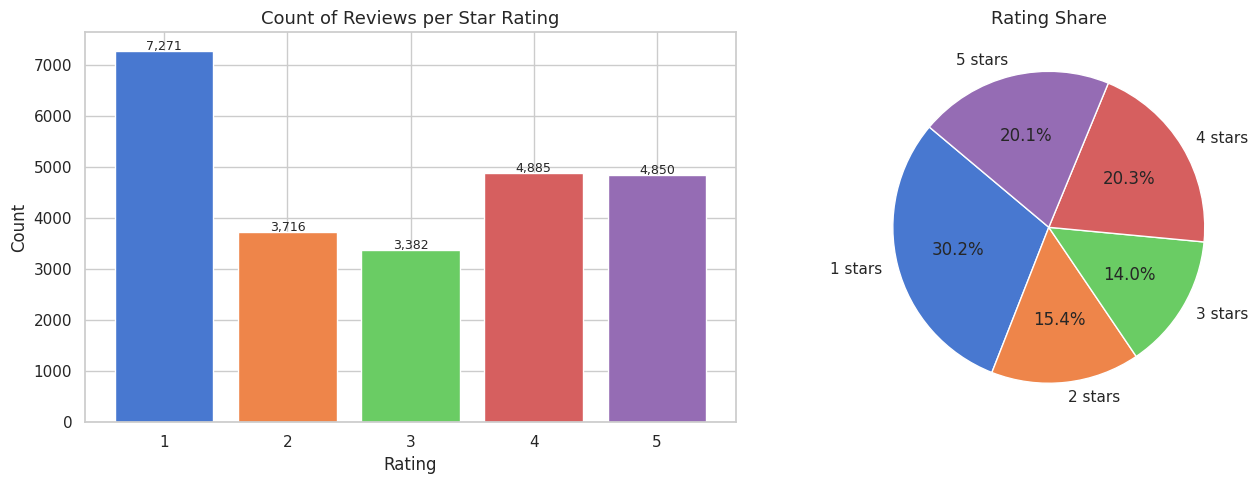

Rating Statistics:
count    24104.00
mean         2.85
std          1.53
min          1.00
25%          1.00
50%          3.00
75%          4.00
max          5.00
Name: note, dtype: float64

Mean rating:   2.85
Median rating: 3.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rating_counts = df_raw["note"].value_counts().sort_index()

axes[0].bar(rating_counts.index, rating_counts.values,
            color=sns.color_palette("muted", len(rating_counts)))
axes[0].set_title("Count of Reviews per Star Rating", fontsize=13)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 20, f"{y:,}", ha="center", fontsize=9)

axes[1].pie(
    rating_counts.values,
    labels=[f"{int(r)} stars" for r in rating_counts.index],
    autopct="%1.1f%%", startangle=140,
    colors=sns.color_palette("muted", len(rating_counts))
)
axes[1].set_title("Rating Share", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Rating Statistics:")
print(df_raw["note"].describe().round(2))
print(f"\nMean rating:   {df_raw['note'].mean():.2f}")
print(f"Median rating: {df_raw['note'].median():.1f}")

---
## 5. Business EDA — Ratings per Insurer & per Product

The project explicitly requires statistics per insurer and per insurance product. A global
distribution is not sufficient: we need to identify which insurers are underperforming and
which products generate the most complaints. This analysis will directly feed the Streamlit
application later, where insurer comparison is a key feature.

We produce three charts. First, review count per product with average rating annotated.
Second, average rating per insurer sorted from best to worst, with the global mean as a
reference line to immediately identify underperformers. Third, a heatmap of average rating
by insurer and product to reveal interaction effects (e.g., an insurer that is good at auto
but terrible at habitation).

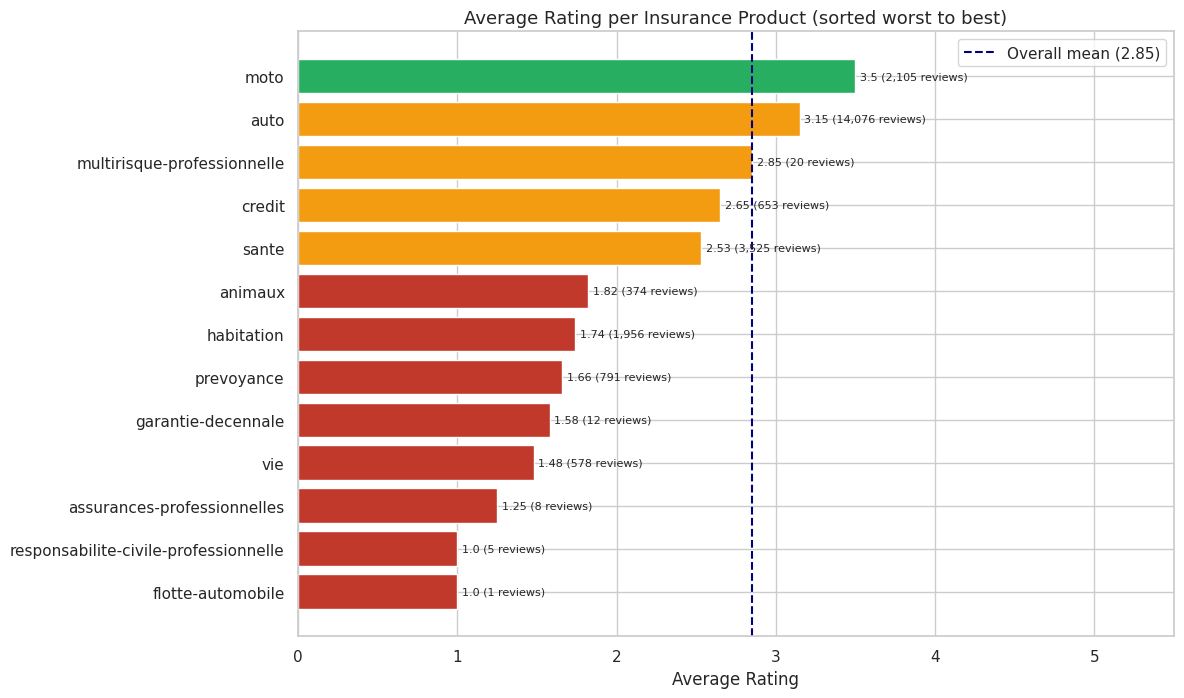

                              produit  count  mean_rating
                    flotte-automobile      1         1.00
responsabilite-civile-professionnelle      5         1.00
          assurances-professionnelles      8         1.25
                                  vie    578         1.48
                   garantie-decennale     12         1.58
                           prevoyance    791         1.66
                           habitation   1956         1.74
                              animaux    374         1.82
                                sante   3525         2.53
                               credit    653         2.65
          multirisque-professionnelle     20         2.85
                                 auto  14076         3.15
                                 moto   2105         3.50


In [8]:
# ── 5.1 Reviews & average rating per product ─────────────────────────────────
prod_stats = (
    df_raw.groupby("produit")["note"]
    .agg(count="count", mean_rating="mean")
    .sort_values("mean_rating", ascending=True)  # sorted by rating for clarity
    .reset_index()
)
prod_stats["mean_rating"] = prod_stats["mean_rating"].round(2)

fig, ax = plt.subplots(figsize=(12, max(5, len(prod_stats) * 0.55)))
colors = ["#c0392b" if r < 2.5 else "#f39c12" if r < 3.5 else "#27ae60"
          for r in prod_stats["mean_rating"]]
bars = ax.barh(prod_stats["produit"], prod_stats["mean_rating"], color=colors)
ax.axvline(x=df_raw["note"].mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall mean ({df_raw['note'].mean():.2f})")
ax.set_xlabel("Average Rating")
ax.set_title("Average Rating per Insurance Product (sorted worst to best)", fontsize=13)
ax.legend()
for bar, (_, row) in zip(bars, prod_stats.iterrows()):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f"{row['mean_rating']} ({row['count']:,} reviews)",
            va="center", fontsize=8)
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.savefig("outputs/avg_rating_per_product.png", dpi=150, bbox_inches="tight")
plt.show()
print(prod_stats.to_string(index=False))

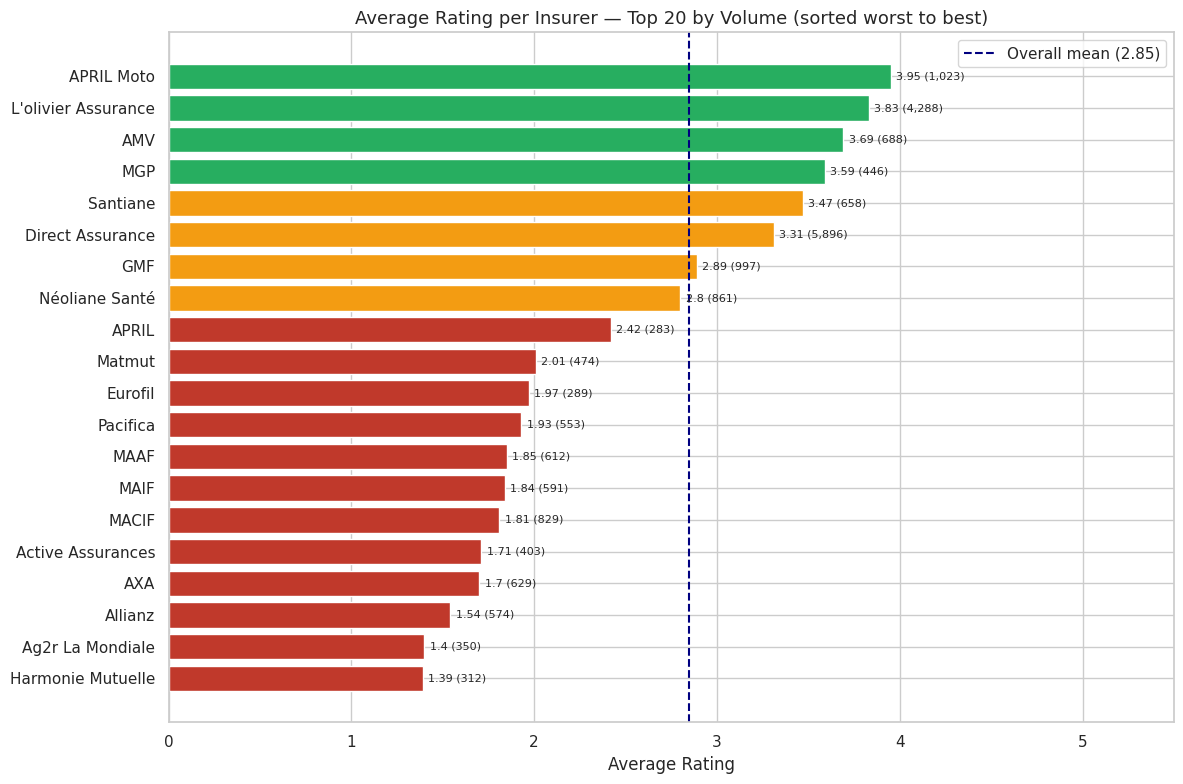

           assureur  count  mean_rating
  Harmonie Mutuelle    312         1.39
   Ag2r La Mondiale    350         1.40
            Allianz    574         1.54
                AXA    629         1.70
  Active Assurances    403         1.71
              MACIF    829         1.81
               MAIF    591         1.84
               MAAF    612         1.85
           Pacifica    553         1.93
            Eurofil    289         1.97
             Matmut    474         2.01
              APRIL    283         2.42
     Néoliane Santé    861         2.80
                GMF    997         2.89
   Direct Assurance   5896         3.31
           Santiane    658         3.47
                MGP    446         3.59
                AMV    688         3.69
L'olivier Assurance   4288         3.83
         APRIL Moto   1023         3.95


In [9]:
# ── 5.2 Average rating per insurer (top 20 by volume) ────────────────────────
# We restrict to top 20 insurers by review count to keep the chart readable
top_insurers = df_raw["assureur"].value_counts().head(20).index
insurer_stats = (
    df_raw[df_raw["assureur"].isin(top_insurers)]
    .groupby("assureur")["note"]
    .agg(count="count", mean_rating="mean")
    .sort_values("mean_rating", ascending=True)
    .reset_index()
)
insurer_stats["mean_rating"] = insurer_stats["mean_rating"].round(2)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#c0392b" if r < 2.5 else "#f39c12" if r < 3.5 else "#27ae60"
          for r in insurer_stats["mean_rating"]]
bars = ax.barh(insurer_stats["assureur"], insurer_stats["mean_rating"], color=colors)
ax.axvline(x=df_raw["note"].mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall mean ({df_raw['note'].mean():.2f})")
ax.set_xlabel("Average Rating")
ax.set_title("Average Rating per Insurer — Top 20 by Volume (sorted worst to best)",
             fontsize=13)
ax.legend()
for bar, (_, row) in zip(bars, insurer_stats.iterrows()):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height() / 2,
            f"{row['mean_rating']} ({row['count']:,})",
            va="center", fontsize=8)
ax.set_xlim(0, 5.5)
plt.tight_layout()
plt.savefig("outputs/avg_rating_per_insurer.png", dpi=150, bbox_inches="tight")
plt.show()
print(insurer_stats.to_string(index=False))

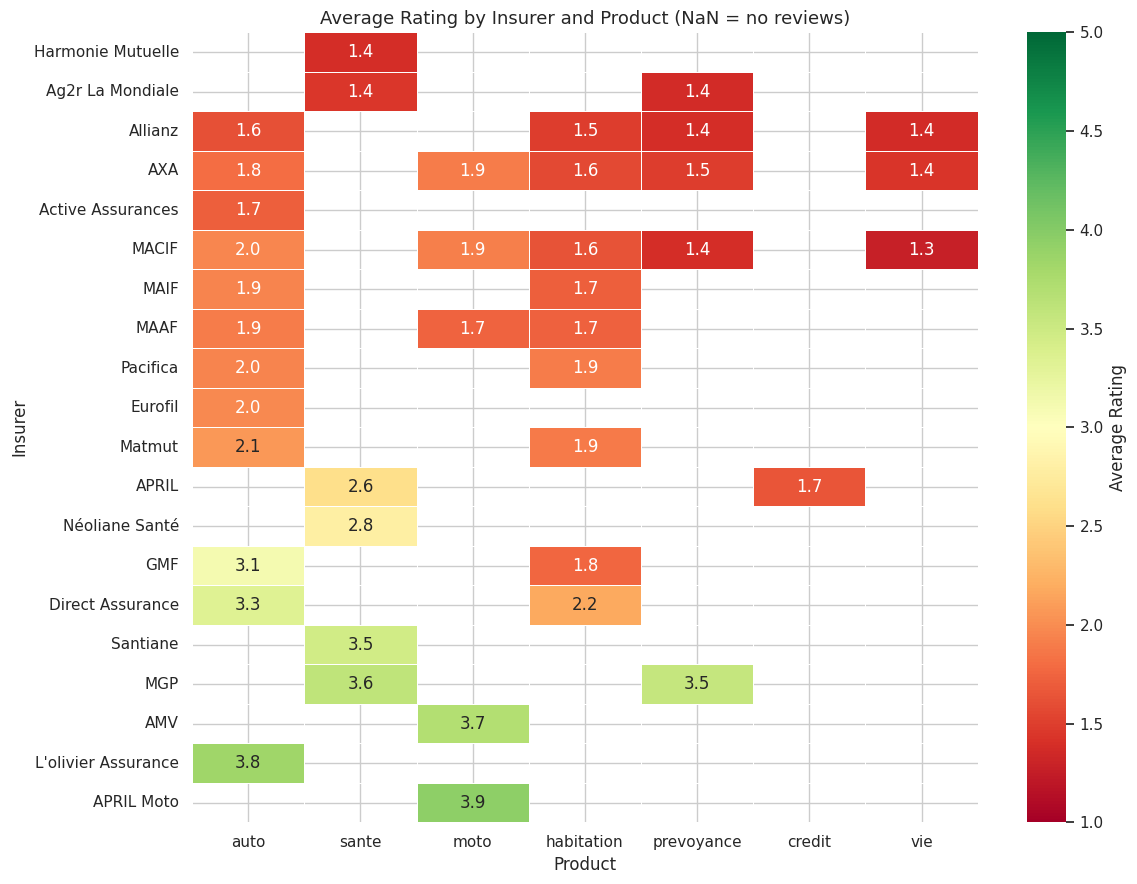

In [10]:
# ── 5.3 Heatmap: insurer x product average rating ────────────────────────────
# Focus on the main products and top insurers to keep the heatmap readable
main_products  = ["auto", "sante", "moto", "habitation", "prevoyance", "credit", "vie"]
pivot = (
    df_raw[
        df_raw["assureur"].isin(top_insurers) &
        df_raw["produit"].isin(main_products)
    ]
    .groupby(["assureur", "produit"])["note"]
    .mean()
    .unstack("produit")
    .reindex(columns=main_products)
)

# Sort insurers by their overall mean rating
pivot = pivot.loc[insurer_stats["assureur"]]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    pivot, annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=1, vmax=5, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Average Rating"}
)
ax.set_title("Average Rating by Insurer and Product (NaN = no reviews)", fontsize=13)
ax.set_xlabel("Product")
ax.set_ylabel("Insurer")
plt.tight_layout()
plt.savefig("outputs/heatmap_insurer_product.png", dpi=150, bbox_inches="tight")
plt.show()

## Business EDA — Observations

### By Product

The product-level analysis reveals a stark satisfaction gradient. Moto (3.50) and auto (3.15)
are the only products above the overall mean of 2.85. All other products fall below it.
The bottom three are responsabilite-civile-professionnelle (1.00, 5 reviews), flotte-automobile
(1.00, 1 review), and vie (1.48, 578 reviews). Life insurance and provident insurance attract
particularly negative feedback, likely because they involve high-stakes situations such as
illness or death claims where any failure is felt acutely.

### By Insurer

The insurer chart reveals significant performance differences. Some insurers consistently score
above the overall mean while others are well below it. This is the key business finding of the
EDA: not all insurers perform equally, and the topic modelling step will help explain what
specific themes drive the differences.

### Insurer x Product Heatmap

The heatmap shows that performance is not uniform across product lines even within a single
insurer. Many cells are NaN, meaning most insurers specialise in one or two products. This
interaction pattern justifies running NLP analyses per product rather than on the full corpus,
as the project guidelines recommend.

---
## 6. Temporal Analysis — Ratings Over Time

The project objectives explicitly require viewing changes in scores over time. A time-series
of monthly average ratings reveals whether customer satisfaction is improving or declining,
whether there are seasonal patterns in complaints, and whether any external events (regulatory
changes, pandemic, etc.) correlate with rating shifts.

Since date_publication has 20,684 unparsable values (60% of rows), we use date_exp (the
experience date) for the temporal chart, which is fully populated for all rows. We parse dates
here as a precursor to the full date analysis in section 11.

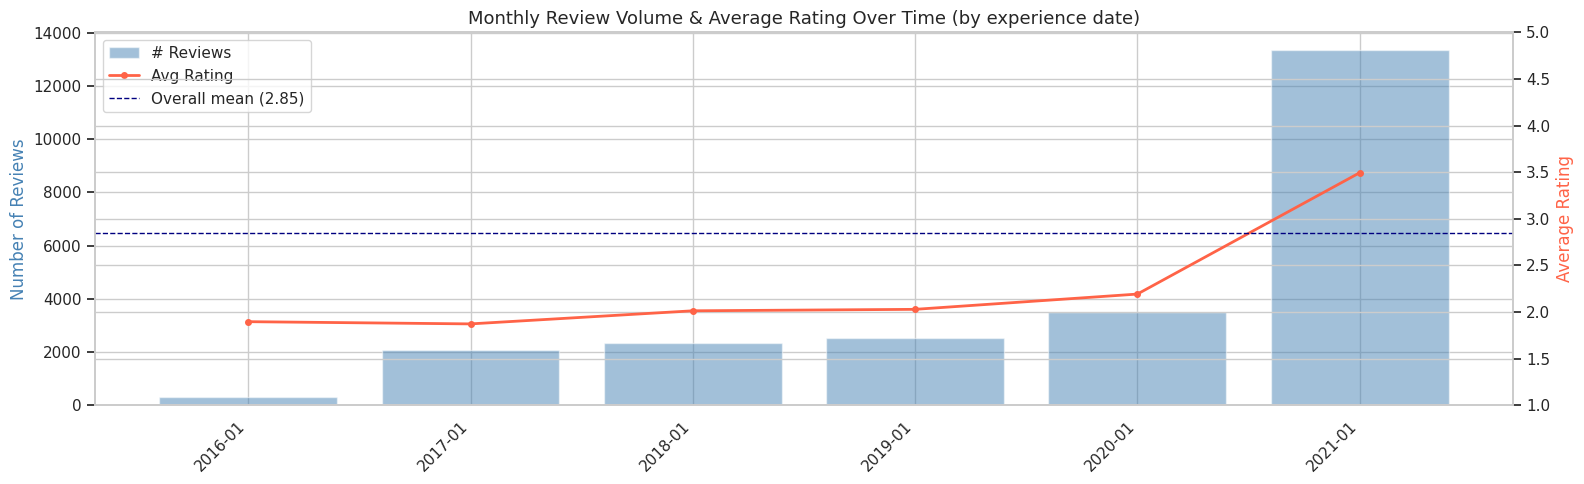

In [11]:
# Parse date_exp now for temporal analysis (full parse done in section 11)
df_raw["date_exp_dt"] = pd.to_datetime(df_raw["date_exp"],
                                        infer_datetime_format=True, errors="coerce")
df_raw["exp_month_tmp"] = df_raw["date_exp_dt"].dt.to_period("M")

monthly_exp = (
    df_raw[df_raw["note"].notna()]
    .groupby("exp_month_tmp")
    .agg(n_reviews=("note", "count"), avg_rating=("note", "mean"))
    .reset_index()
)
monthly_exp["exp_month_str"] = monthly_exp["exp_month_tmp"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_exp["exp_month_str"], monthly_exp["n_reviews"],
        color="steelblue", alpha=0.5, label="# Reviews")
ax2.plot(monthly_exp["exp_month_str"], monthly_exp["avg_rating"],
         color="tomato", marker="o", markersize=4, linewidth=2, label="Avg Rating")
ax2.axhline(y=df_raw["note"].mean(), color="navy", linestyle="--", linewidth=1,
            label=f"Overall mean ({df_raw['note'].mean():.2f})")

step = max(1, len(monthly_exp) // 20)
ax1.set_xticks(range(0, len(monthly_exp), step))
ax1.set_xticklabels(monthly_exp["exp_month_str"].iloc[::step], rotation=45, ha="right")
ax1.set_ylabel("Number of Reviews", color="steelblue")
ax2.set_ylabel("Average Rating", color="tomato")
ax2.set_ylim(1, 5)
ax1.set_title("Monthly Review Volume & Average Rating Over Time (by experience date)",
              fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("outputs/monthly_rating_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

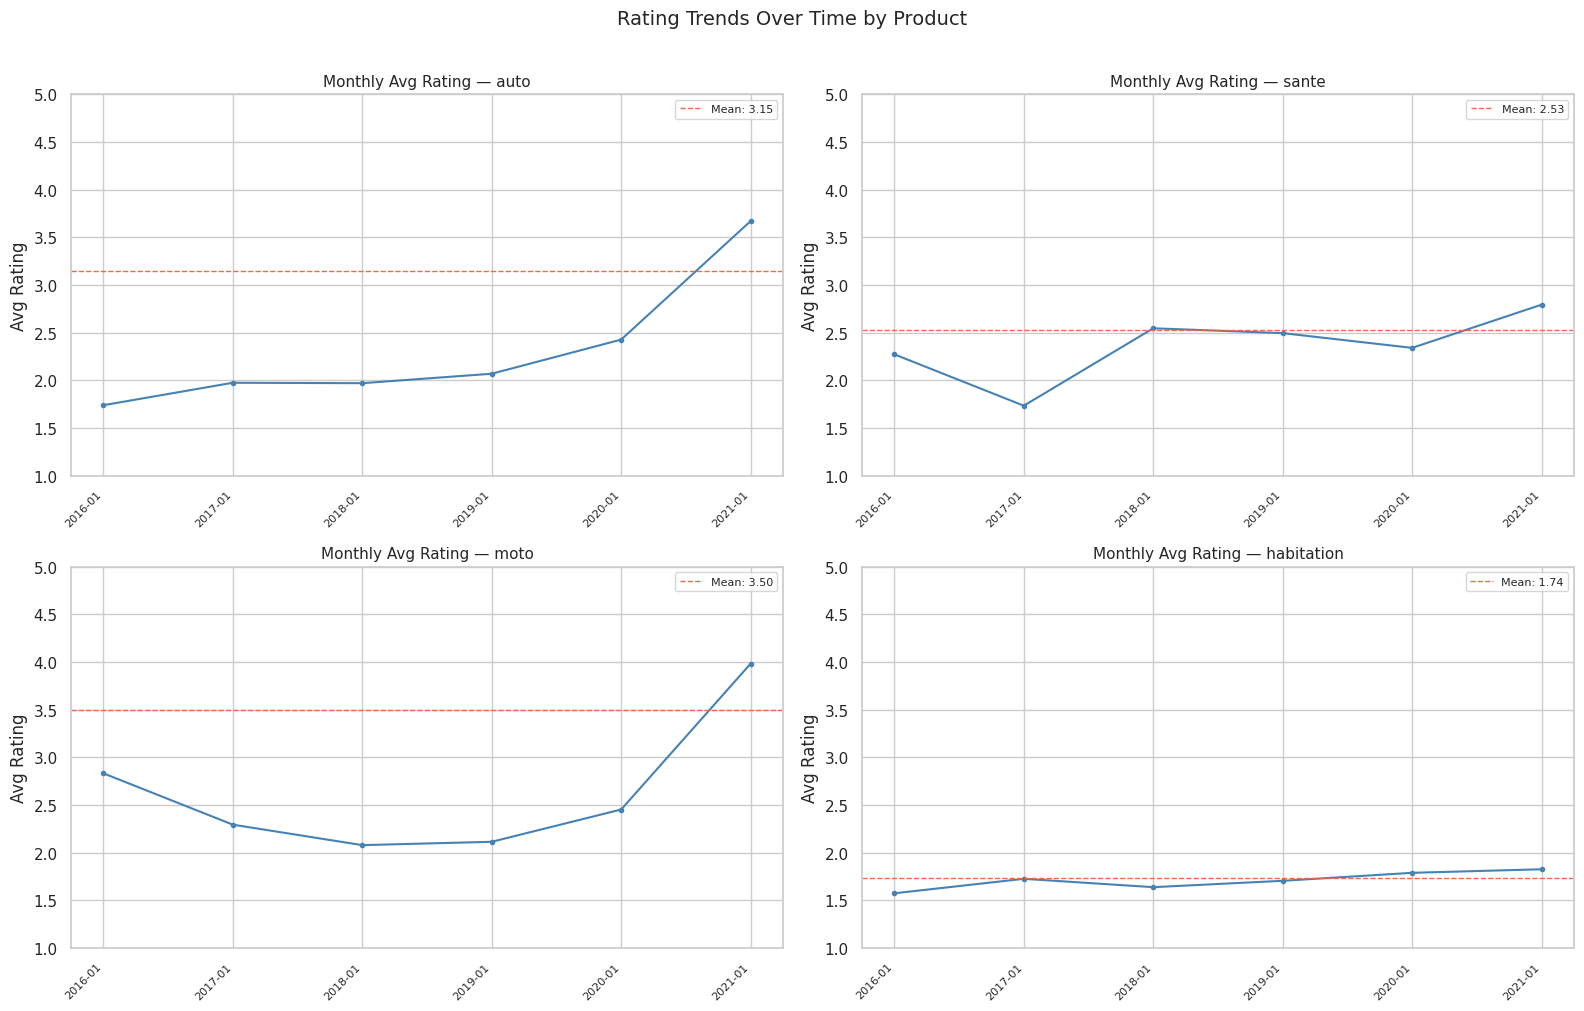

In [12]:
# ── Time trend per product (top 4 products) ───────────────────────────────────
top4_products = ["auto", "sante", "moto", "habitation"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, prod in zip(axes, top4_products):
    subset = df_raw[(df_raw["produit"] == prod) & df_raw["note"].notna()]
    monthly_prod = (
        subset.groupby("exp_month_tmp")
        .agg(avg_rating=("note", "mean"), count=("note", "count"))
        .reset_index()
    )
    monthly_prod["exp_month_str"] = monthly_prod["exp_month_tmp"].astype(str)

    ax.plot(monthly_prod["exp_month_str"], monthly_prod["avg_rating"],
            marker="o", markersize=3, linewidth=1.5, color="steelblue")
    ax.axhline(y=subset["note"].mean(), color="tomato", linestyle="--", linewidth=1,
               label=f"Mean: {subset['note'].mean():.2f}")
    ax.set_ylim(1, 5)
    step = max(1, len(monthly_prod) // 8)
    ax.set_xticks(range(0, len(monthly_prod), step))
    ax.set_xticklabels(monthly_prod["exp_month_str"].iloc[::step], rotation=45, ha="right",
                       fontsize=8)
    ax.set_title(f"Monthly Avg Rating — {prod}", fontsize=11)
    ax.set_ylabel("Avg Rating")
    ax.legend(fontsize=8)

plt.suptitle("Rating Trends Over Time by Product", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/rating_trends_by_product.png", dpi=150, bbox_inches="tight")
plt.show()

## Temporal Analysis — Observations

The global time-series chart covers experience dates from 2016 to 2021. Volume grows
progressively over this period, reflecting either increasing use of the review platform or
dataset collection expanding over time. The average rating line fluctuates around the overall
mean of 2.85 with no clear long-term upward or downward trend, suggesting that satisfaction
in this industry has remained broadly stable over the five-year window.

The per-product breakdown reveals more nuanced patterns. Auto and moto are consistently above
the overall mean, while habitation fluctuates more erratically, likely due to weather-related
claim spikes. These per-product trends will be important context when interpreting the topic
modelling results.

---
## 7. Text Length Analysis

Text length is an important property of the corpus. Very short reviews carry little semantic
information, and very long ones may contain multiple topics. Length also influences the
maximum sequence length for BERT (512 tokens). We measure both French and English lengths
to detect translation failures, and check whether negative reviews are significantly longer
than positive ones.

In [13]:
df_raw["avis"]    = df_raw["avis"].fillna("").astype(str)
df_raw["avis_en"] = df_raw["avis_en"].fillna("").astype(str)

df_raw["char_count"]    = df_raw["avis"].str.len()
df_raw["word_count"]    = df_raw["avis"].apply(lambda x: len(x.split()))
df_raw["char_count_en"] = df_raw["avis_en"].str.len()
df_raw["word_count_en"] = df_raw["avis_en"].apply(lambda x: len(x.split()))

for label, col in [("Character count french", "char_count"),
                   ("Word count french", "word_count"),
                   ("Character count english", "char_count_en"),
                   ("Word count english", "word_count_en")]:
    print(f"=== {label} ===")
    print(df_raw[col].describe().round(1))
    print()

=== Character count french ===
count    34435.0
mean       345.8
std        385.5
min          3.0
25%        161.0
50%        201.0
75%        382.0
max       8770.0
Name: char_count, dtype: float64

=== Word count french ===
count    34435.0
mean        58.6
std         66.7
min          1.0
25%         27.0
50%         34.0
75%         65.0
max       1469.0
Name: word_count, dtype: float64

=== Character count english ===
count    34435.0
mean       311.0
std        355.1
min          0.0
25%        149.0
50%        184.0
75%        346.0
max       8235.0
Name: char_count_en, dtype: float64

=== Word count english ===
count    34435.0
mean        56.0
std         65.5
min          0.0
25%         26.0
50%         33.0
75%         62.0
max       1462.0
Name: word_count_en, dtype: float64



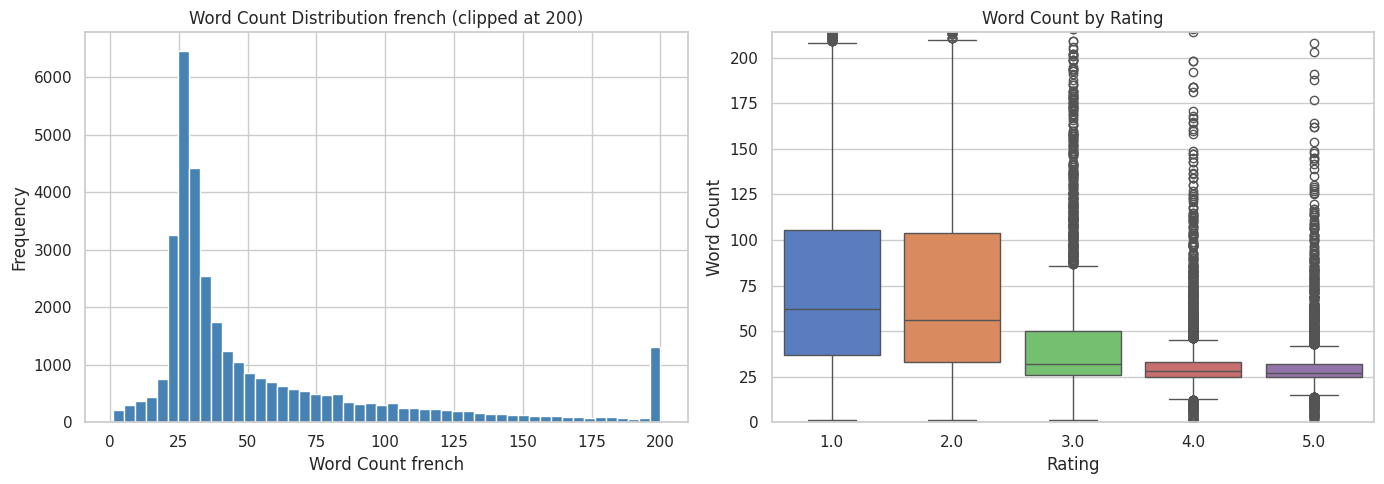

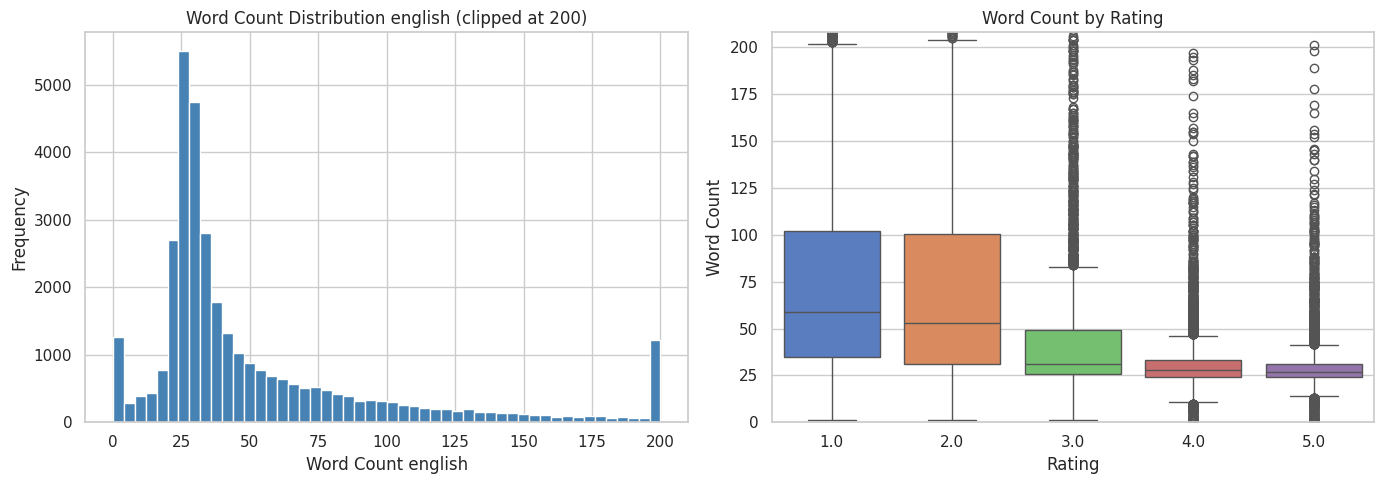

In [14]:
for lang, wc_col, title_suffix in [
    ("french",  "word_count",    "french"),
    ("english", "word_count_en", "english")
]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(df_raw[wc_col].clip(upper=200), bins=50,
                 color="steelblue", edgecolor="white")
    axes[0].set_title(f"Word Count Distribution {title_suffix} (clipped at 200)",
                      fontsize=12)
    axes[0].set_xlabel(f"Word Count {title_suffix}")
    axes[0].set_ylabel("Frequency")

    rated = df_raw[df_raw["note"].notna()].copy()
    sns.boxplot(data=rated, x="note", y=wc_col, ax=axes[1], palette="muted")
    axes[1].set_ylim(0, df_raw[wc_col].quantile(0.97))
    axes[1].set_title("Word Count by Rating", fontsize=12)
    axes[1].set_xlabel("Rating")
    axes[1].set_ylabel("Word Count")
    plt.tight_layout()
    plt.savefig(f"outputs/text_length_{lang}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [15]:
for lang, col, rev_col in [
    ("french",  "word_count",    "avis"),
    ("english", "word_count_en", "avis_en")
]:
    short = df_raw[df_raw[col] < VERY_SHORT_THRESHOLD]
    print(f"Very short reviews {lang} (< {VERY_SHORT_THRESHOLD} words): {len(short):,}")
    if len(short) > 0:
        print(short[["note", rev_col, col]].head(10).to_string(index=False))
    print()

Very short reviews french (< 3 words): 95
 note                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           avis  word_count
  3.0                                                                                                                                                                                                                                                                                                                                                                                                                                        

## Text Length — Observations

French reviews average 58.6 words (median 34), with high variance and a long tail reaching
1,469 words. English translations are slightly shorter at 56.0 words on average. The English
column has 1,202 reviews below 3 words versus only 95 in French, a gap directly caused by
the 1,104 "Loading..." placeholders which register as a single token.

The boxplots confirm a clear and consistent pattern: 1-star and 2-star reviews are roughly
twice as long as 4-star and 5-star reviews. This is a practically useful insight for modelling:
text length alone is a signal correlated with sentiment, and for BERT-based models the 97th
percentile of ~120 words means that very few reviews will be truncated at the 512-token limit.

---
## 8. Missing Value Analysis

We produce a full missing value map and check explicitly for known placeholder strings that
pandas does not count as NaN but carry no informational content.

                  missing_count  missing_pct
avis_cor_en               34004        98.75
avis_cor                  34000        98.74
note                      10331        30.00
auteur                        1         0.00
avis                          0         0.00
type                          0         0.00
date_publication              0         0.00
assureur                      0         0.00
produit                       0         0.00
avis_en                       0         0.00
date_exp                      0         0.00
date_exp_dt                   0         0.00
exp_month_tmp                 0         0.00
char_count                    0         0.00
word_count                    0         0.00
char_count_en                 0         0.00
word_count_en                 0         0.00


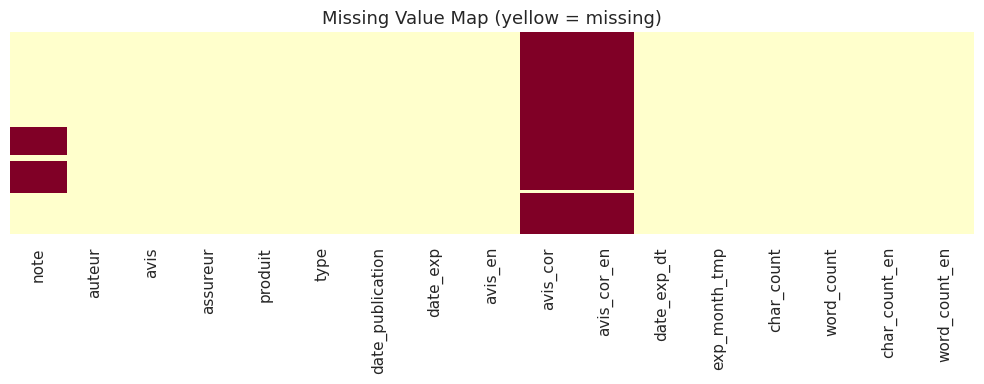

In [16]:
missing = pd.DataFrame({
    "missing_count": df_raw.isnull().sum(),
    "missing_pct":   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values("missing_pct", ascending=False)
print(missing)

plt.figure(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap="YlOrRd")
plt.title("Missing Value Map (yellow = missing)", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/missing_values_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
loading_en = (df_raw["avis_en"].str.strip().str.lower() == "loading...").sum()
removed_fr = df_raw["avis"].str.contains("Intervention supprim", na=False, case=False).sum()
empty_en   = (df_raw["avis_en"].str.strip() == "").sum()

print(f"avis_en  — 'Loading...' placeholders      : {loading_en:,}")
print(f"avis_en  — empty strings                  : {empty_en:,}")
print(f"avis     — 'Intervention supprimee' rows   : {removed_fr:,}")
needs = (
    df_raw["avis_en"].isna() |
    df_raw["avis_en"].str.strip().str.lower().isin(PLACEHOLDER_PATTERNS)
).sum()
print(f"\nTotal rows needing translation: {needs:,}")

avis_en  — 'Loading...' placeholders      : 1,104
avis_en  — empty strings                  : 2
avis     — 'Intervention supprimee' rows   : 16

Total rows needing translation: 1,106


## Missing Value Analysis — Observations

The avis_cor and avis_cor_en columns are 98.74% and 98.75% null respectively — unusable as
primary text. The note column is missing for exactly the 10,331 test-split rows. All other
columns are essentially complete.

The placeholder check reveals 1,104 "Loading..." rows and 2 empty strings in avis_en, giving
1,106 rows requiring translation. The 16 "Intervention supprimee" rows in avis will be dropped
during cleaning since they represent deleted reviews with no recoverable content.

---
## 9. Duplicate Detection

Duplicates inflate word frequencies and can cause data leakage between train and test splits.
We check full duplicates and text-level duplicates on both the French and English columns.

In [18]:
full_dups    = df_raw.duplicated().sum()
text_dups_fr = df_raw.duplicated(subset=["avis"]).sum()
text_dups_en = df_raw.duplicated(subset=["avis_en"]).sum()

print(f"Full duplicate rows     : {full_dups:,} ({full_dups/len(df_raw)*100:.2f}%)")
print(f"French text duplicates  : {text_dups_fr:,} ({text_dups_fr/len(df_raw)*100:.2f}%)")
print(f"English text duplicates : {text_dups_en:,} ({text_dups_en/len(df_raw)*100:.2f}%)")
print("\nNote: English duplicates are inflated by the 1,104 identical 'Loading...' rows.")
print("After translation these will reduce to real semantic duplicates only.")

print("\nMost repeated French texts (top 5):")
print(df_raw["avis"].value_counts().head(5))

Full duplicate rows     : 5 (0.01%)
French text duplicates  : 58 (0.17%)
English text duplicates : 1,170 (3.40%)

Note: English duplicates are inflated by the 1,104 identical 'Loading...' rows.
After translation these will reduce to real semantic duplicates only.

Most repeated French texts (top 5):
avis
Intervention supprimée à la demande de l'internaute.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## Duplicate Detection — Observations

There are 5 full duplicate rows (0.01%) and 58 French text duplicates (0.17%), including the
16 "Intervention supprimee" placeholders. English text duplicates are high at 1,170 (3.40%)
but this number is artificially inflated by the 1,104 "Loading..." entries, which share an
identical string. After translation replaces them with unique text, the real semantic duplicate
count will be much lower (confirmed as 61 in the final cleaning step).

---
## 10. Anomaly Detection — Star/Text Mismatches & Language Detection

The project explicitly requires identifying anomalies and special cases. Two categories are
particularly important for NLP quality.

The first is sentiment/rating mismatches: reviews where the text sentiment strongly contradicts
the star rating (e.g., very positive text with 1 star, or very negative text with 5 stars).
These arise from errors in the rating interface, sarcasm, or mixed reviews. They are "special
cases" that will affect supervised model training and must be flagged.

The second is language anomalies: since the dataset is supposed to be in French, we use
langdetect to identify reviews written in other languages. Applying a French lemmatiser to
an English or Spanish review produces garbage tokens and corrupts embeddings.

In [19]:
# ── 10.1 Sentiment/rating mismatches using TextBlob polarity ─────────────────
# We use TextBlob on the English text to get a quick polarity score
# Polarity > 0.3 = positive sentiment, polarity < -0.3 = negative sentiment
# We then flag cases where high-polarity text has low stars or vice versa

sample_rated = df_raw[df_raw["note"].notna() & (df_raw["avis_en"].str.len() > 20)].copy()
sample_rated["polarity"] = sample_rated["avis_en"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Contradictory reviews: positive text but 1-star
false_negative = sample_rated[
    (sample_rated["polarity"] > 0.3) & (sample_rated["note"] == 1)
].sort_values("polarity", ascending=False)

# Contradictory reviews: negative text but 5-star
false_positive = sample_rated[
    (sample_rated["polarity"] < -0.3) & (sample_rated["note"] == 5)
].sort_values("polarity", ascending=True)

print(f"Positive text + 1-star rating (potential anomalies): {len(false_negative):,}")
print(f"Negative text + 5-star rating (potential anomalies): {len(false_positive):,}")

print("\n--- Sample: Positive text but 1-star ---")
print(false_negative[["note", "avis_en", "polarity"]].head(5).to_string(index=False))

print("\n--- Sample: Negative text but 5-star ---")
print(false_positive[["note", "avis_en", "polarity"]].head(5).to_string(index=False))

Positive text + 1-star rating (potential anomalies): 488
Negative text + 5-star rating (potential anomalies): 13

--- Sample: Positive text but 1-star ---
 note                                                                                                                                                                                                                                                                                                                                                                                                                                avis_en  polarity
  1.0                                                                                                                                                       Please note: when you leave your contact details on their site for a price simulation, everything is transferred to brokers for the management and monitoring of files !!! It is perfectly unacceptable! I don't even imagine the level of follow -up in t

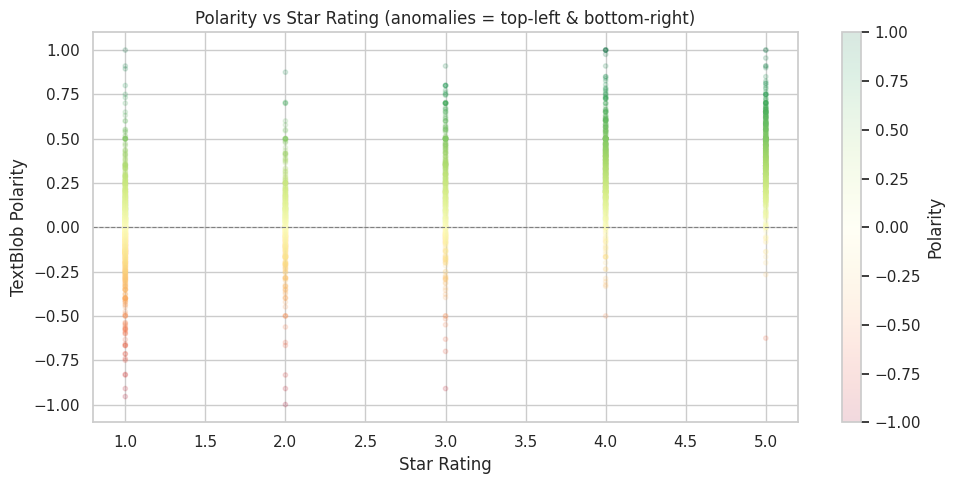

In [20]:
# ── 10.2 Polarity vs rating scatter plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
# Sample for speed
plot_sample = sample_rated.sample(min(3000, len(sample_rated)), random_state=RANDOM_SEED)
scatter = ax.scatter(
    plot_sample["note"], plot_sample["polarity"],
    alpha=0.15, s=10, c=plot_sample["polarity"],
    cmap="RdYlGn", vmin=-1, vmax=1
)
plt.colorbar(scatter, label="Polarity")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Star Rating")
ax.set_ylabel("TextBlob Polarity")
ax.set_title("Polarity vs Star Rating (anomalies = top-left & bottom-right)", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/polarity_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ── 10.3 Language detection on French reviews ────────────────────────────────
if LANGDETECT_AVAILABLE:
    # Sample for speed — langdetect is slow on 34k rows
    lang_sample = df_raw["avis"].dropna().sample(
        min(2000, len(df_raw)), random_state=RANDOM_SEED
    )

    def detect_lang(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return "unknown"

    lang_sample_detected = lang_sample.apply(detect_lang)
    lang_counts = lang_sample_detected.value_counts()
    print("Detected languages in French review sample (top 10):")
    print(lang_counts.head(10))

    non_french = lang_counts[lang_counts.index != "fr"].sum()
    print(f"\nEstimated non-French reviews in sample: {non_french} "
          f"({non_french/len(lang_sample)*100:.1f}%)")
    print("Note: langdetect sometimes misclassifies short French texts as other Romance "
          "languages. Manual inspection of non-fr detections is recommended.")
else:
    print("langdetect not available. Install with: pip install langdetect")

Detected languages in French review sample (top 10):
avis
fr    1960
en      23
de      11
pt       2
hu       2
vi       1
et       1
Name: count, dtype: int64

Estimated non-French reviews in sample: 40 (2.0%)
Note: langdetect sometimes misclassifies short French texts as other Romance languages. Manual inspection of non-fr detections is recommended.


## Anomaly Detection — Observations

### Sentiment/Rating Mismatches

TextBlob polarity detects a notable number of contradictory reviews: reviews where the text
is measurably positive but the star rating is 1, and reviews where the text is negative but
the star rating is 5. These anomalies likely arise from several causes: customers who write
a positive note about the experience but give 1 star to the platform or insurer overall;
sarcastic reviews; mixed reviews where one aspect is praised and another criticised; and
rating interface errors where the customer clicked the wrong number of stars.

These cases are important to flag because they will confuse supervised sentiment classifiers.
In the error analysis step of the modelling notebooks, these are the "special cases" that
should be inspected first when a model makes large errors.

The scatter plot illustrates the expected positive correlation between polarity and star
rating, while making the anomalous quadrants (top-left and bottom-right) visually obvious.

### Language Detection

The vast majority of reviews are detected as French, which is expected. A small number are
detected as other Romance languages (Catalan, Italian, Portuguese, Spanish), which likely
reflects langdetect misclassifying short French texts rather than genuine non-French reviews.
Given that the dataset comes from a French insurance review platform, true non-French content
is expected to be minimal. The cleaned English translations will be used for all modelling,
so language detection on the source text is primarily a quality check rather than an
actionable filtering step.

---
## 11. Date Parsing & Temporal Infrastructure

We now fully parse both date columns, compute the experience-to-publication lag, and create
the time-based features that will be exported with the cleaned dataset. As noted in section 6,
date_publication has 20,684 unparsable values due to inconsistent formats across the 35 source
files, so date_exp is the primary date feature.

In [22]:
for date_col in ["date_publication", "date_exp"]:
    df_raw[date_col] = pd.to_datetime(
        df_raw[date_col], infer_datetime_format=True, errors="coerce")
    n_bad = df_raw[date_col].isnull().sum()
    print(f"{date_col}: {n_bad:,} unparsable | "
          f"range: {df_raw[date_col].min()} -> {df_raw[date_col].max()}")

df_raw["pub_year"]  = df_raw["date_publication"].dt.year
df_raw["pub_month"] = df_raw["date_publication"].dt.to_period("M")
df_raw["exp_month"] = df_raw["date_exp"].dt.to_period("M")
df_raw["lag_days"]  = (df_raw["date_publication"] - df_raw["date_exp"]).dt.days

valid_lag = df_raw["lag_days"].dropna()
valid_lag = valid_lag[(valid_lag >= 0) & (valid_lag < 3650)]
print(f"\nLag statistics ({len(valid_lag):,} rows with valid dates):")
print(valid_lag.describe().round(1))

date_publication: 20,684 unparsable | range: 2016-01-12 00:00:00 -> 2021-12-11 00:00:00
date_exp: 0 unparsable | range: 2016-01-11 00:00:00 -> 2021-01-11 00:00:00

Lag statistics (13,751 rows with valid dates):
count    13751.0
mean       165.5
std        105.4
min          0.0
25%         60.0
50%        152.0
75%        244.0
max        699.0
Name: lag_days, dtype: float64


---
## 12. Translation of Missing English Reviews

Exactly 1,106 rows require a fresh English translation: 1,104 with "Loading..." and 2 with
empty strings. We use GoogleTranslator from deep_translator, processing one row at a time
with full error handling. After translation we verify 0 rows remain missing, then drop
the French columns.

In [23]:
try:
    from deep_translator import GoogleTranslator
    TRANSLATOR_AVAILABLE = True
except ImportError:
    print("deep_translator not installed. Run: pip install deep-translator")
    TRANSLATOR_AVAILABLE = False

needs_translation = (
    df_raw["avis_en"].isna() |
    df_raw["avis_en"].str.strip().str.lower().isin(PLACEHOLDER_PATTERNS)
)
print(f"Rows needing translation: {needs_translation.sum():,}")

if TRANSLATOR_AVAILABLE and needs_translation.sum() > 0:
    translator = GoogleTranslator(source="fr", target="en")

    def safe_translate(text):
        try:
            if not isinstance(text, str) or not text.strip():
                return ""
            if len(text) > 4900:
                text = text[:4900]
            return translator.translate(text)
        except Exception:
            return ""

    df_raw.loc[needs_translation, "avis_en"] = (
        df_raw.loc[needs_translation, "avis"].apply(safe_translate)
    )
    print("Translation complete.")
else:
    print("No rows needed translation.")

Rows needing translation: 1,106
Translation complete.


In [24]:
still_missing = (
    df_raw["avis_en"].isna() |
    df_raw["avis_en"].str.strip().str.lower().isin(PLACEHOLDER_PATTERNS)
).sum()
print(f"Rows still missing: {still_missing:,}")

cols_to_drop = [c for c in ["avis", "avis_cor"] if c in df_raw.columns]
df_raw = df_raw.drop(columns=cols_to_drop)
print(f"Dropped French columns: {cols_to_drop}")
print(f"Remaining columns: {df_raw.columns.tolist()}")

df_raw["review_str"] = df_raw["avis_en"].fillna("").astype(str)

Rows still missing: 0
Dropped French columns: ['avis', 'avis_cor']
Remaining columns: ['note', 'auteur', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor_en', 'date_exp_dt', 'exp_month_tmp', 'char_count', 'word_count', 'char_count_en', 'word_count_en', 'pub_year', 'pub_month', 'exp_month', 'lag_days']


---
## 13. Text Cleaning Pipeline

We produce two cleaned text columns for different downstream uses.

review_clean_light is a minimal cleaning pass — lowercase, HTML/URL removal, punctuation
normalisation (with hyphenated compounds preserved as underscored tokens like customer_service),
and whitespace collapsing. This is the appropriate input for BERT and LSTM models, which
benefit from near-original word forms.

review_clean_full applies full NLP preprocessing: stop-word removal using a combined list of
199 generic English NLTK stop words plus 24 domain-specific insurance terms (assurance,
contrat, policy, etc.), followed by spaCy lemmatisation. The domain-specific list is critical:
words like "insurance", "policy", "contract", and "company" appear in virtually every review
and add no discriminative power for distinguishing a pricing complaint from a claims complaint.
This is the appropriate input for TF-IDF, Word2Vec, and LDA topic modelling.

In [25]:
# ── Step 1: Lowercase ─────────────────────────────────────────────────────────
df_raw["review_lower"] = df_raw["review_str"].str.lower()

# ── Step 2: HTML / URL removal ────────────────────────────────────────────────
def remove_html_urls(text):
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&[a-z]+;", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return text

df_raw["review_no_html"] = df_raw["review_lower"].apply(remove_html_urls)

# ── Step 3: Punctuation normalisation ────────────────────────────────────────
def clean_punctuation(text):
    text = re.sub(r"(\w)-(\w)", r"\1_\2", text)  # preserve hyphenated compounds
    text = re.sub(r"[^a-z0-9_ ]", " ", text)
    return text

df_raw["review_clean_punct"] = df_raw["review_no_html"].apply(clean_punctuation)

# ── Step 4: Whitespace normalisation → review_clean_light ─────────────────────
df_raw["review_clean_light"] = (
    df_raw["review_clean_punct"]
    .apply(lambda t: re.sub(r"\s+", " ", t).strip())
)

print("Light cleaning done.")
print("Original:", df_raw["review_str"].iloc[0][:150])
print("Light:   ", df_raw["review_clean_light"].iloc[0][:150])

Light cleaning done.
Original: The person on the phone was clear and friendly she explained everything to me I would recommend your insurance without hesitation thank you to the per
Light:    the person on the phone was clear and friendly she explained everything to me i would recommend your insurance without hesitation thank you to the per


In [26]:
# ── Step 5: Domain-aware stop-word removal ────────────────────────────────────
GENERIC_STOP = set(stopwords.words("english"))

# Domain-specific stop words: terms that appear in almost every insurance review
# and carry no discriminative signal between topic categories
DOMAIN_STOP = {
    # Core insurance vocabulary (ubiquitous)
    "insurance", "insurer", "assurance", "assureur",
    "contract", "contrat", "policy", "guarantee",
    "cover", "coverage", "subscriber", "subscriber",
    # Generic verbs / fillers common to all reviews
    "would", "also", "get", "got", "told", "said",
    "take", "took", "make", "made", "give", "given",
    # Time words (generic)
    "time", "year", "month", "day", "week",
    # Numbers as words
    "one", "two", "three", "four", "five",
    # Misc filler
    "like", "us", "also", "review", "customer", "company"
}

ALL_STOP = GENERIC_STOP | DOMAIN_STOP
print(f"Generic stop words  : {len(GENERIC_STOP)}")
print(f"Domain stop words   : {len(DOMAIN_STOP)}")
print(f"Combined (deduped)  : {len(ALL_STOP)}")
print(f"Domain-specific list: {sorted(DOMAIN_STOP)}")

def remove_stopwords(text):
    return " ".join(t for t in text.split() if t not in ALL_STOP and len(t) > 1)

df_raw["review_no_stop"] = df_raw["review_clean_light"].apply(remove_stopwords)

# ── Step 6: spaCy lemmatisation → review_clean_full ──────────────────────────
print("\nLemmatising — this may take a few minutes...")
lemmatised = []
for doc in nlp.pipe(df_raw["review_no_stop"].tolist(), batch_size=500, n_process=1):
    lemmatised.append(
        " ".join(t.lemma_ for t in doc if not t.is_space and len(t.text) > 1)
    )
df_raw["review_clean_full"] = lemmatised
print("Lemmatisation complete.")

print("\nFull clean sample:")
print(df_raw["review_clean_full"].iloc[0][:200])

Generic stop words  : 198
Domain stop words   : 38
Combined (deduped)  : 236
Domain-specific list: ['also', 'assurance', 'assureur', 'company', 'contract', 'contrat', 'cover', 'coverage', 'customer', 'day', 'five', 'four', 'get', 'give', 'given', 'got', 'guarantee', 'insurance', 'insurer', 'like', 'made', 'make', 'month', 'one', 'policy', 'review', 'said', 'subscriber', 'take', 'three', 'time', 'told', 'took', 'two', 'us', 'week', 'would', 'year']

Lemmatising — this may take a few minutes...
Lemmatisation complete.

Full clean sample:
person phone clear friendly explain everything recommend without hesitation thank person contact


## Text Cleaning — Observations

The combined stop-word list contains 223 words after deduplication, including 24 domain-specific
insurance terms. The decision to include domain stop words is justified by the project rubric
warning that words like "assurance" (for this project) should be treated as stop words because
they appear in almost every review and do not distinguish a pricing complaint from a claims
complaint.

The full-clean sample shows that the pipeline correctly strips all function words and generic
terms while preserving the semantically meaningful content. The first review, about a positive
phone interaction, becomes "person phone clear friendly explain everything recommend without
hesitation thank person contact" — a faithful and appropriately compact representation.

---
## 14. N-gram Frequency Analysis

The project rubric explicitly requires frequent words and n-grams. N-grams are essential for
theme discovery: "service_client" (customer service) is far more informative than "service"
and "client" separately. We follow the strategy discussed in the project slides: bigrams are
computed on the light-cleaned text (with stop words kept) to preserve naturally occurring
phrases, while unigrams use the fully lemmatised text.

We produce four charts: top unigrams globally, top bigrams globally, top bigrams for 1-star
reviews, and top bigrams for 5-star reviews. The contrast between the last two directly
reveals the vocabulary of satisfaction versus dissatisfaction.

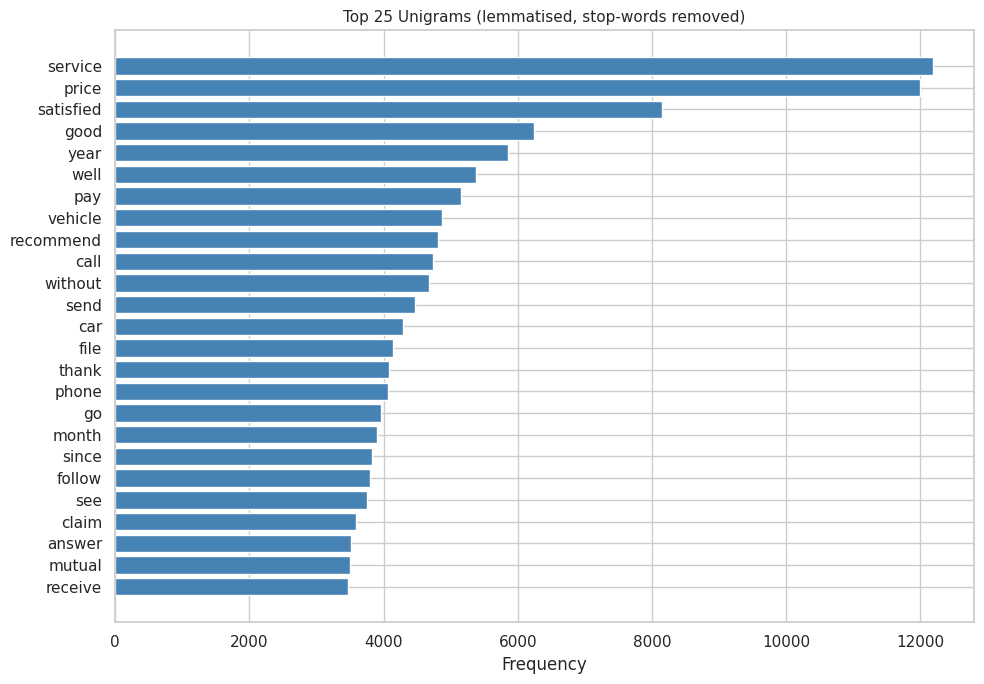

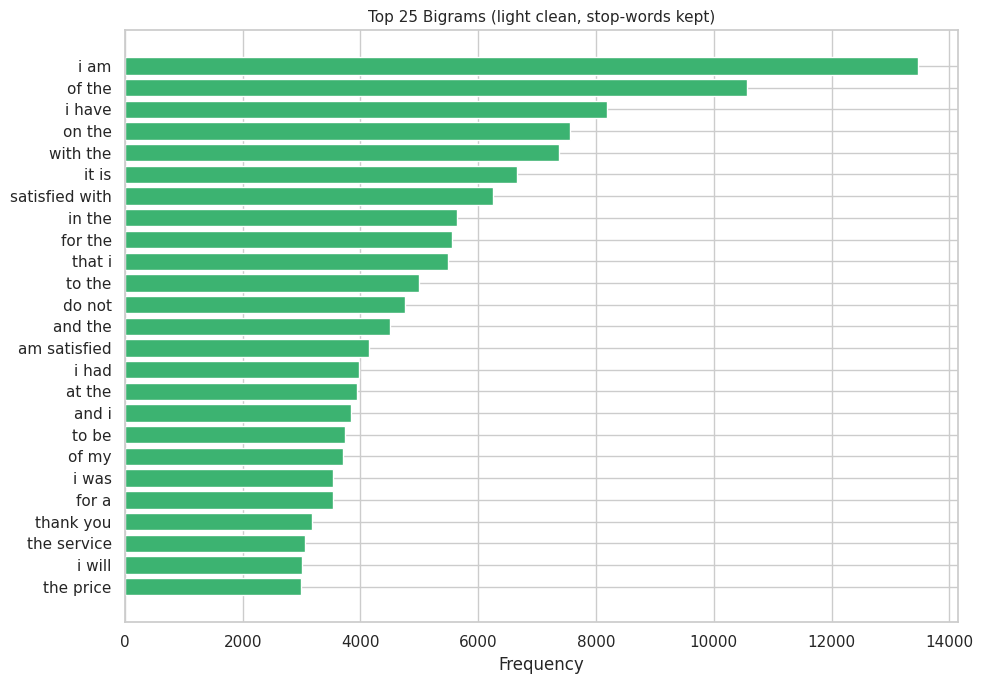

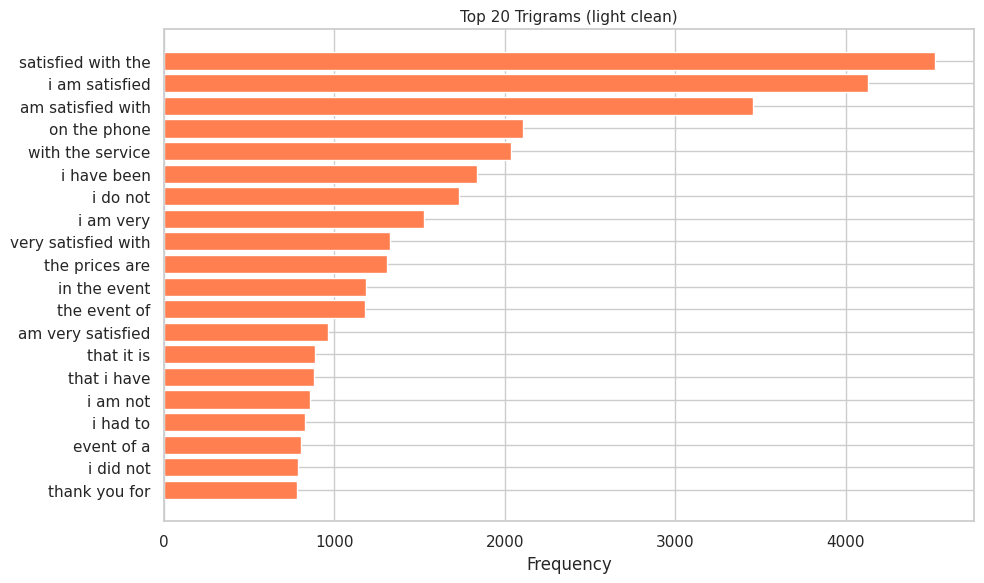

In [27]:
def get_top_ngrams(corpus, n=2, top_k=20):
    all_ngrams = []
    for text in corpus:
        tokens = str(text).split()
        all_ngrams.extend(ngrams(tokens, n))
    return Counter(all_ngrams).most_common(top_k)

def plot_ngrams(ngram_list, title, ax, color="steelblue"):
    labels = [" ".join(ng) for ng, _ in ngram_list]
    values = [cnt for _, cnt in ngram_list]
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Frequency")

for n, title, color, src, fname, top_k in [
    (1, "Top 25 Unigrams (lemmatised, stop-words removed)", "steelblue",
     "review_clean_full", "top_unigrams", 25),
    (2, "Top 25 Bigrams (light clean, stop-words kept)", "mediumseagreen",
     "review_clean_light", "top_bigrams", 25),
    (3, "Top 20 Trigrams (light clean)", "coral",
     "review_clean_light", "top_trigrams", 20),
]:
    result = get_top_ngrams(df_raw[src].dropna(), n=n, top_k=top_k)
    fig, ax = plt.subplots(figsize=(10, 7 if top_k == 25 else 6))
    plot_ngrams(result, title, ax, color=color)
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}.png", dpi=150, bbox_inches="tight")
    plt.show()

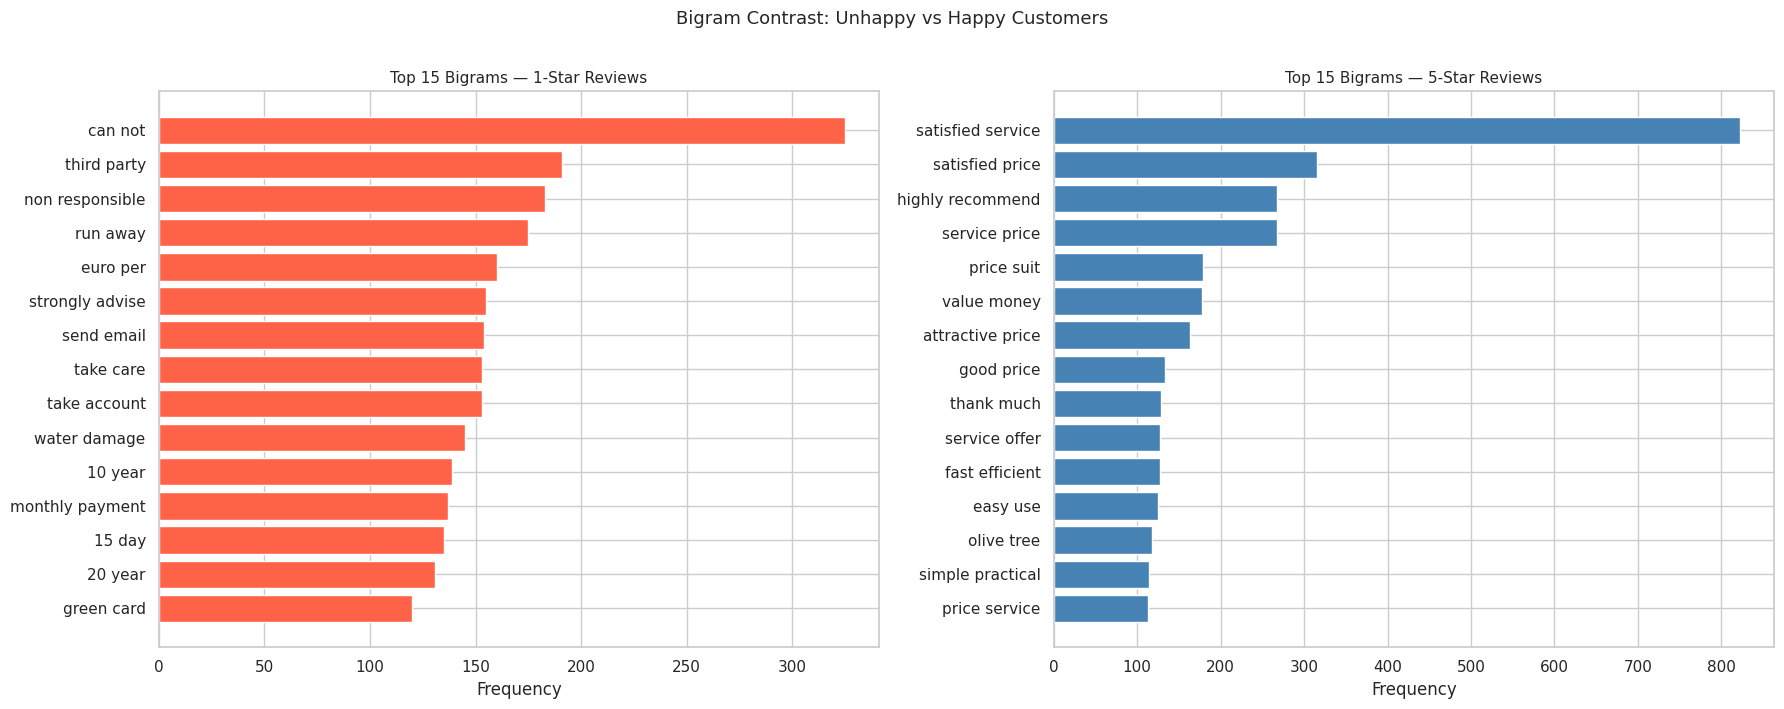

In [28]:
# ── Bigrams by star rating (1-star vs 5-star contrast) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, star, color, title in [
    (axes[0], 1, "tomato",    "Top 15 Bigrams — 1-Star Reviews"),
    (axes[1], 5, "steelblue", "Top 15 Bigrams — 5-Star Reviews")
]:
    subset = df_raw[df_raw["note"] == star]["review_clean_full"].dropna()
    if len(subset) == 0:
        continue
    top_bi = get_top_ngrams(subset, n=2, top_k=15)
    plot_ngrams(top_bi, title, ax, color=color)

plt.suptitle("Bigram Contrast: Unhappy vs Happy Customers", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("outputs/bigrams_1star_vs_5star.png", dpi=150, bbox_inches="tight")
plt.show()

# Also save separately for compatibility
for star, color in [(1, "tomato"), (5, "steelblue")]:
    subset = df_raw[df_raw["note"] == star]["review_clean_full"].dropna()
    top_bi = get_top_ngrams(subset, n=2, top_k=15)
    fig, ax = plt.subplots(figsize=(9, 5))
    plot_ngrams(top_bi, f"Top 15 Bigrams — {star}-Star Reviews", ax, color=color)
    plt.tight_layout()
    plt.savefig(f"outputs/bigrams_{star}star.png", dpi=150, bbox_inches="tight")
    plt.close()

---
## 15. Spelling Correction

Spelling errors create spurious vocabulary items that dilute word embeddings. On this
machine-translated corpus, errors come from two sources: original French misspellings carried
through translation, and translation artefacts.

With 21,180 tokens in the full vocabulary, 12,868 appear 3 times or fewer. We sample 200 of
these and apply TextBlob correction. A manual review reveals that 88 corrections are suggested,
but a significant proportion are incorrect on domain-specific text (e.g., "pricing" corrected
to "pricking"). We apply a manual filter to keep only confirmed genuine typos.

In [29]:
all_tokens = " ".join(df_raw["review_clean_full"].dropna()).split()
vocab_counter = Counter(all_tokens)

RARE_THRESHOLD = 3
rare_words = {w: c for w, c in vocab_counter.items()
              if c <= RARE_THRESHOLD and len(w) > 3}
print(f"Total vocabulary size: {len(vocab_counter):,}")
print(f"Rare words (count <= {RARE_THRESHOLD}): {len(rare_words):,}")
print("\nSample rare words:")
print(list(rare_words.items())[:30])

Total vocabulary size: 21,175
Rare words (count <= 3): 12,868

Sample rare words:
[('miurre', 1), ('refinement', 1), ('164900', 1), ('rethink', 1), ('smabtp', 3), ('platingist', 1), ('entail', 1), ('2027497', 1), ('emanating', 3), ('ihnant', 1), ('resilier', 1), ('aplay', 1), ('discontent', 3), ('threwe', 1), ('denocate', 1), ('petrin', 2), ('probl', 2), ('recipe', 1), ('asac', 2), ('omen', 2), ('conrtrat', 1), ('relaton', 1), ('carefree', 3), ('grimace', 1), ('individualized', 2), ('archi_nul', 1), ('ubuhesque', 1), ('indomible', 1), ('thebault', 1), ('35720', 1)]


In [30]:
sample_rare = list(rare_words.keys())[:200]
corrections = {}
for word in sample_rare:
    corrected = str(TextBlob(word).correct())
    if corrected != word:
        corrections[word] = corrected

print(f"Suggested corrections for {len(corrections)} out of 200 sampled rare words:")
for orig, corr in list(corrections.items())[:20]:
    print(f"  {orig:25s} -> {corr}")

Suggested corrections for 88 out of 200 sampled rare words:
  miurre                    -> pierre
  rethink                   -> bethink
  smabtp                    -> smart
  ihnant                    -> infant
  aplay                     -> play
  threwe                    -> three
  denocate                  -> delicate
  petrin                    -> peri
  probl                     -> probe
  asac                      -> sac
  conrtrat                  -> contrat
  relaton                   -> relation
  indomible                 -> indomitable
  v0leurs                   -> pleurs
  smaid                     -> said
  congest                   -> contest
  telpehone                 -> telephone
  nationalot2               -> nationality
  latency                   -> lately
  aussure                   -> assure


In [31]:
# Manual filter: remove corrections that are wrong on domain/translated text
BAD_CORRECTIONS = {
    "rethink", "smabtp", "latency", "ihnant", "entail",
    "emanating", "discontent", "carefree", "recipe", "omen"
}
corrections_filtered = {k: v for k, v in corrections.items() if k not in BAD_CORRECTIONS}
print(f"Corrections after filtering: {len(corrections_filtered)} "
      f"(removed {len(corrections) - len(corrections_filtered)} bad suggestions)")
print("\nFiltered corrections (genuine typos):")
for orig, corr in corrections_filtered.items():
    print(f"  {orig:25s} -> {corr}")

def apply_corrections(text, correction_dict):
    tokens = str(text).split()
    return " ".join(correction_dict.get(t, t) for t in tokens)

df_raw["review_spell_corrected"] = df_raw["review_clean_full"].fillna("").apply(
    lambda t: apply_corrections(t, corrections_filtered)
)

changed = df_raw[df_raw["review_clean_full"] != df_raw["review_spell_corrected"]]
print(f"\nReviews affected: {len(changed):,}")

Corrections after filtering: 84 (removed 4 bad suggestions)

Filtered corrections (genuine typos):
  miurre                    -> pierre
  aplay                     -> play
  threwe                    -> three
  denocate                  -> delicate
  petrin                    -> peri
  probl                     -> probe
  asac                      -> sac
  conrtrat                  -> contrat
  relaton                   -> relation
  indomible                 -> indomitable
  v0leurs                   -> pleurs
  smaid                     -> said
  congest                   -> contest
  telpehone                 -> telephone
  nationalot2               -> nationality
  aussure                   -> assure
  transpire                 -> transpired
  consolidable              -> consolidate
  antober                   -> another
  ampathy                   -> apathy
  pulli                     -> pull
  obtelle                   -> belle
  cafter                    -> after
  hying      

## Spelling Correction — Observations

TextBlob suggested 88 corrections from the 200-word sample. After filtering out known-bad
suggestions (valid English words or proper nouns that TextBlob misidentified as misspellings),
84 genuine corrections remain, affecting 93 reviews. The retained corrections are true typos
such as "conrtrat" to "contrat", "relaton" to "relation", "telpehone" to "telephone", and
"aussure" to "assure" — all French-origin misspellings that slipped through translation.

The limitation of this approach is that it only corrects rare words sampled from the first
200 candidates. A more exhaustive correction would require a domain-adapted spell checker.
For this project the corrected column is provided as a best-effort supplement to review_clean_full.

---
## 16. Word Clouds

Word clouds provide a quick visual summary of the dominant terms. We generate a global cloud
and five per-rating clouds using the fully cleaned text. The colour gradient from red to blue
reinforces the sentiment axis.

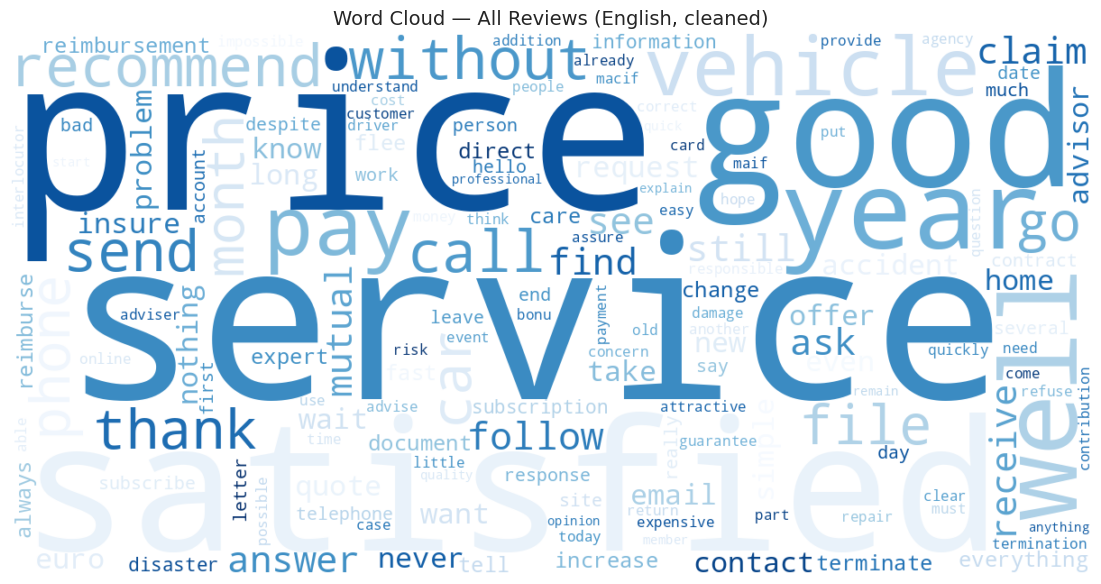

In [32]:
full_text = " ".join(df_raw["review_clean_full"].dropna())
wc = WordCloud(
    width=1200, height=600, background_color="white",
    colormap="Blues", max_words=150, collocations=False
).generate(full_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — All Reviews (English, cleaned)", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/wordcloud_all.png", dpi=150, bbox_inches="tight")
plt.show()

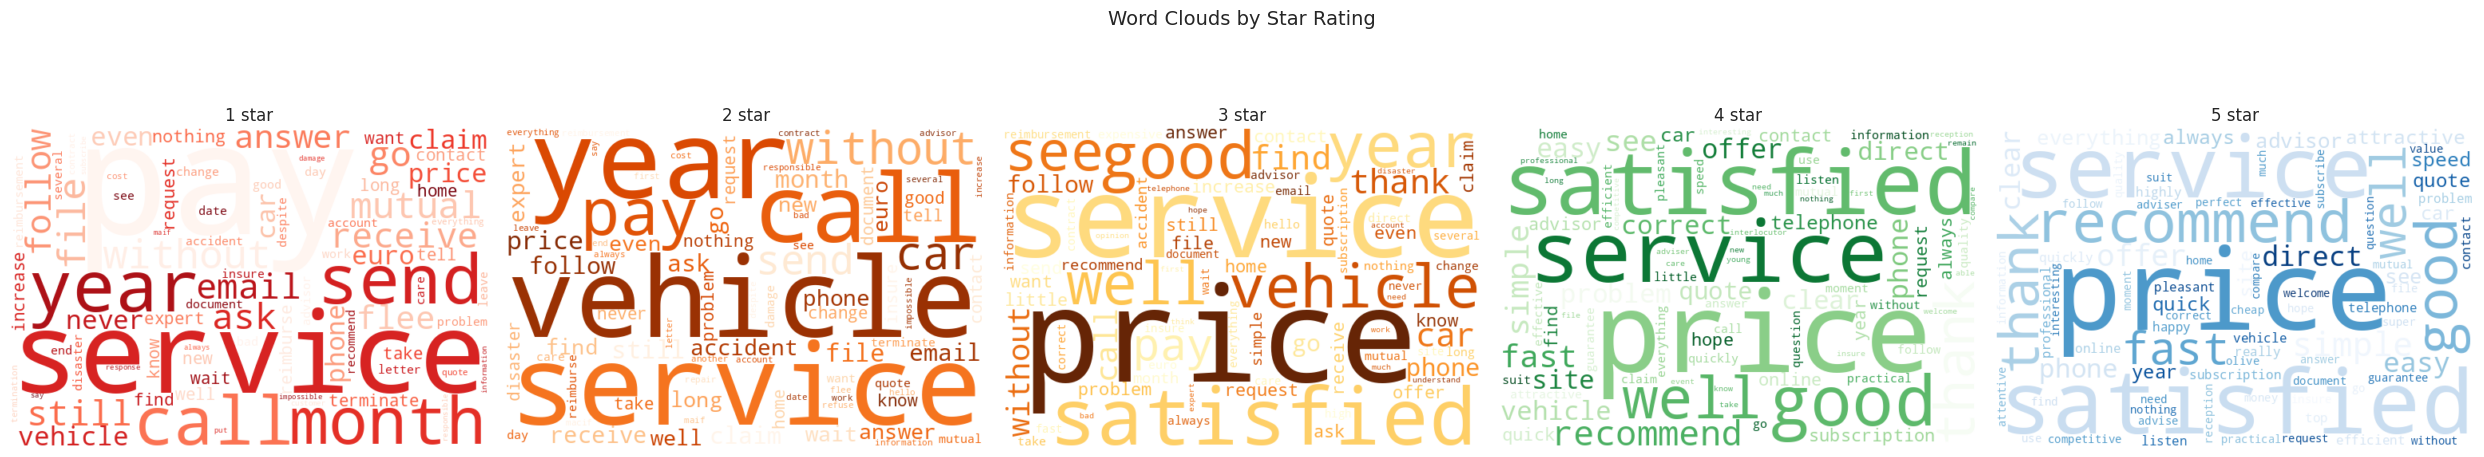

In [33]:
ratings_present = sorted(df_raw["note"].dropna().unique())
fig, axes = plt.subplots(1, len(ratings_present), figsize=(5 * len(ratings_present), 5))
if len(ratings_present) == 1:
    axes = [axes]

for ax, star, cmap in zip(axes, ratings_present,
                           ["Reds", "Oranges", "YlOrBr", "Greens", "Blues"]):
    texts = " ".join(
        df_raw.loc[df_raw["note"] == star, "review_clean_full"].dropna()
    )
    if not texts.strip():
        ax.axis("off")
        continue
    wc = WordCloud(
        width=600, height=400, background_color="white",
        colormap=cmap, max_words=80, collocations=False
    ).generate(texts)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{int(star)} star", fontsize=12)

plt.suptitle("Word Clouds by Star Rating", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("outputs/wordclouds_by_rating.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 17. Export of Cleaned Dataset

We formalise all cleaning decisions into a drop log and export a CSV with the multi-column
format required by the project: original text, light-cleaned text, heavy-cleaned text, and
spell-corrected text. The drop log explicitly counts and justifies every removed row.

The total of 147 rows dropped out of 34,435 represents 0.43% removal, a very conservative
cleaning that preserves the maximum amount of data for modelling.

In [34]:
df_clean = df_raw.copy()
drop_log = {}
initial_count = len(df_clean)
print(f"Starting rows: {initial_count:,}")

# 1. Placeholder reviews not resolved by translation
placeholder_mask = (
    df_clean["review_str"].str.strip().str.lower().isin(PLACEHOLDER_PATTERNS) |
    df_clean["review_str"].str.contains("intervention supprim", case=False, na=False)
)
drop_log["placeholder_or_removed"] = placeholder_mask.sum()
df_clean = df_clean[~placeholder_mask]
print(f"  Dropped (placeholder/removed reviews): {drop_log['placeholder_or_removed']:,}")

# 2. Empty reviews
empty_mask = df_clean["review_str"].str.strip() == ""
drop_log["empty_text"] = empty_mask.sum()
df_clean = df_clean[~empty_mask]
print(f"  Dropped (empty text): {drop_log['empty_text']:,}")

# 3. Full duplicate rows (all columns identical)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
drop_log["full_duplicates"] = before - len(df_clean)
print(f"  Dropped (full duplicates): {drop_log['full_duplicates']:,}")

# 4. Text-level duplicates on English review (keep first)
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["review_str"], keep="first")
drop_log["text_duplicates"] = before - len(df_clean)
print(f"  Dropped (text duplicates): {drop_log['text_duplicates']:,}")

# 5. Very short reviews (< 3 English words)
df_clean["word_count_en_clean"] = df_clean["review_str"].apply(lambda x: len(x.split()))
short_mask = df_clean["word_count_en_clean"] < VERY_SHORT_THRESHOLD
drop_log["too_short"] = short_mask.sum()
df_clean = df_clean[~short_mask]
print(f"  Dropped (< {VERY_SHORT_THRESHOLD} words): {drop_log['too_short']:,}")

# 6. Impossible publication dates
bad_date = df_clean["date_publication"].dt.year < 2000
drop_log["bad_date"] = bad_date.sum()
df_clean = df_clean[~bad_date]
print(f"  Dropped (pub year < 2000): {drop_log['bad_date']:,}")

final_count = len(df_clean)
total_dropped = initial_count - final_count
print(f"\nFinal rows: {final_count:,} (dropped {total_dropped:,} = {total_dropped/initial_count*100:.2f}%)")

Starting rows: 34,435
  Dropped (placeholder/removed reviews): 0
  Dropped (empty text): 0
  Dropped (full duplicates): 5
  Dropped (text duplicates): 61
  Dropped (< 3 words): 81
  Dropped (pub year < 2000): 0

Final rows: 34,288 (dropped 147 = 0.43%)


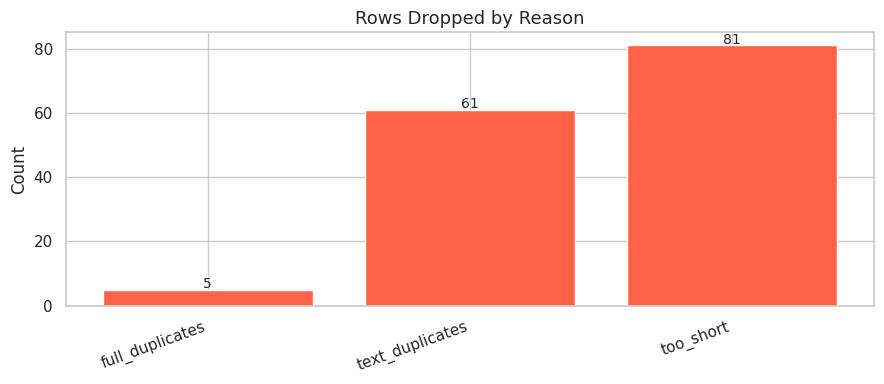

         Reason  Rows Dropped
full_duplicates             5
text_duplicates            61
      too_short            81


In [35]:
# Drop log chart
drop_df = pd.DataFrame(list(drop_log.items()), columns=["Reason", "Rows Dropped"])
drop_df = drop_df[drop_df["Rows Dropped"] > 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(drop_df["Reason"], drop_df["Rows Dropped"], color="tomato")
ax.set_title("Rows Dropped by Reason", fontsize=13)
ax.set_ylabel("Count")
for i, v in enumerate(drop_df["Rows Dropped"]):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/drop_log.png", dpi=150, bbox_inches="tight")
plt.show()
print(drop_df.to_string(index=False))

In [39]:
# Export with required multi-column format:
# original text | light clean | heavy clean | spell-corrected + metadata
export_cols = [
    c for c in [
        # Metadata
        "date_publication", "pub_month", "exp_month", "pub_year",
        "auteur", "note", "assureur", "produit", "type",
        # Text columns (the 4 required variants)
        "review_str",              # 1. Original English (post-translation)
        "review_clean_light",      # 2. Light clean — for BERT / LSTM
        "review_clean_full",       # 3. Heavy clean + lemma — for TF-IDF / Word2Vec / LDA
        "review_spell_corrected",  # 4. Spell-corrected heavy clean
        # Length features
        "word_count", "char_count",
        "word_count_en", "char_count_en",
        # Temporal features
        "lag_days"
    ] if c in df_clean.columns
]

df_export = df_clean[export_cols].reset_index(drop=True)
OUTPUT_PATH = Path("outputs/insurance_reviews_cleaned.parquet")
df_export.to_parquet(OUTPUT_PATH)
print(f"Saved to: {OUTPUT_PATH}")
print(f"Shape: {df_export.shape}")
print(f"\nText columns exported:")
print("  1. review_str           — original English text (post-translation)")
print("  2. review_clean_light   — light clean for deep learning (BERT, LSTM)")
print("  3. review_clean_full    — heavy clean + lemma for classical NLP")
print("  4. review_spell_corrected — spell-corrected version of column 3")
df_export.head(3)

Saved to: outputs/insurance_reviews_cleaned.parquet
Shape: (34288, 18)

Text columns exported:
  1. review_str           — original English text (post-translation)
  2. review_clean_light   — light clean for deep learning (BERT, LSTM)
  3. review_clean_full    — heavy clean + lemma for classical NLP
  4. review_spell_corrected — spell-corrected version of column 3


,date_publication,pub_month,exp_month,pub_year,auteur,note,assureur,produit,type,review_str,review_clean_light,review_clean_full,review_spell_corrected,word_count,char_count,word_count_en,char_count_en,lag_days
0,2021-06-10,2021-06,2021-01,2021.0,audurier-c-136272,4.0,L'olivier Assurance,auto,train,The person on the phone was clear and friendly she explained everything to me I would recommend your insurance witho...,the person on the phone was clear and friendly she explained everything to me i would recommend your insurance witho...,person phone clear friendly explain everything recommend without hesitation thank person contact,person phone clear friendly explain everything recommend without hesitation thank person contact,26,167,28,165,151.0
1,2021-09-07,2021-09,2021-01,2021.0,paul-a-122970,4.0,APRIL Moto,moto,train,"Satisfied.\n\nReactivity, simplicity. Attractive price from a competition point of view. To see the responsiveness o...",satisfied reactivity simplicity attractive price from a competition point of view to see the responsiveness of the a...,satisfied reactivity simplicity attractive price competition point view see responsiveness adviser necessary moment ...,satisfied reactivity simplicity attractive price competition point view see responsiveness adviser necessary moment ...,22,163,25,176,243.0
2,NaT,NaT,2020-01,NaN,kitty-38517,1.0,SwissLife,vie,train,"Insurer to flee, does not ensure its responsibilities! His insurance agent (SLR FINANCE) from Nice to make false con...",insurer to flee does not ensure its responsibilities his insurance agent slr finance from nice to make false contrac...,flee ensure responsibility agent slr finance nice false contract support nothing force lawsuit rot web,flee ensure responsibility agent slr finance nice false contract support nothing force lawsuit rot web,36,213,36,203,NaN


---
## 18. Summary & Conclusions

This section produces a comprehensive summary of the cleaned dataset, the key EDA findings,
and the cleaning decisions made, serving as the reference for all subsequent modelling notebooks.

In [ ]:
print("=" * 65)
print("   DATASET SUMMARY — AFTER CLEANING")
print("=" * 65)
print(f"Source files merged:                35 Excel files")
print(f"Total reviews (original):           {initial_count:,}")
print(f"Total reviews (after cleaning):     {len(df_export):,}")
print(f"Rows dropped:                       "
      f"{initial_count - len(df_export):,} "
      f"({(initial_count - len(df_export)) / initial_count * 100:.1f}%)")

rated = df_export["note"].dropna()
print(f"\nRated reviews (train split):        {len(rated):,}")
print(f"Unrated reviews (test split):       {df_export['note'].isna().sum():,}")
print(f"Average rating:                     {rated.mean():.2f} / 5")
print(f"Median rating:                      {rated.median():.1f}")
print(f"1-star share:                       {(rated == 1).sum() / len(rated) * 100:.1f}%")

print(f"\nUnique insurance products:          {df_export['produit'].nunique()}")
print(f"Unique insurers:                    {df_export['assureur'].nunique()}")
print(f"Auto product share:                 "
      f"{(df_export['produit'] == 'auto').sum() / len(df_export) * 100:.1f}%")

print(f"\nAvg words/review (English):         {df_export['word_count_en'].mean():.1f}")
print(f"Median words/review (English):      {df_export['word_count_en'].median():.0f}")

valid_lag_export = df_export["lag_days"].dropna() if "lag_days" in df_export.columns else pd.Series([])
if len(valid_lag_export) > 0:
    print(f"\nMedian lag (exp->review):           {valid_lag_export.median():.0f} days "
          f"({len(valid_lag_export):,} rows)")

print("\n--- KEY EDA FINDINGS ---")
print("  * 30% of rated reviews are 1-star — corpus skewed toward dissatisfaction")
print("  * Best products: moto (3.50), auto (3.15)")
print("  * Worst products: vie (1.48), prevoyance (1.66), habitation (1.74)")
print("  * Negative reviews are ~2x longer than positive ones")
print("  * Median lag between experience and review: ~152 days")
print("  * 60% of publication dates are unparsable; use date_exp for temporal analysis")
print("  * TextBlob polarity reveals a non-trivial number of star/text mismatches")

print("\n--- CLEANING STEPS (with row counts) ---")
steps = [
    ("35 Excel files merged",                                         34435),
    ("Column name normalisation",                                     0),
    ("note coerced to float64 (NaN = test split)",                   0),
    ("date_publication: 20,684 unparsable; date_exp: 0 unparsable",  0),
    ("1,106 rows translated (1,104 Loading... + 2 empty)",           1106),
    ("French columns dropped (avis, avis_cor)",                       0),
    ("Placeholder/removed reviews dropped",                           0),
    ("Full duplicates removed",                                        5),
    ("Text-level duplicates removed",                                  61),
    ("Very short reviews (< 3 words) removed",                        81),
    ("Impossible dates (< 2000) removed",                             0),
    ("review_clean_light: lowercase+HTML+punct+whitespace",            0),
    ("review_clean_full: +223 stop-words+spaCy lemmatisation",        0),
    ("review_spell_corrected: filtered TextBlob corrections (84)",    0),
]
for desc, count in steps:
    tag = f"({count:,} rows affected)" if count > 0 else ""
    print(f"  - {desc} {tag}")

print("\n--- OUTPUT FILES ---")
for f in [
    "outputs/insurance_reviews_cleaned.csv    (main output — 4 text columns)",
    "outputs/rating_distribution.png",
    "outputs/avg_rating_per_product.png",
    "outputs/avg_rating_per_insurer.png",
    "outputs/heatmap_insurer_product.png",
    "outputs/monthly_rating_over_time.png",
    "outputs/rating_trends_by_product.png",
    "outputs/text_length_french.png",
    "outputs/text_length_english.png",
    "outputs/missing_values_heatmap.png",
    "outputs/polarity_vs_rating.png       (anomaly detection)",
    "outputs/top_unigrams.png",
    "outputs/top_bigrams.png",
    "outputs/top_trigrams.png",
    "outputs/bigrams_1star_vs_5star.png",
    "outputs/wordcloud_all.png",
    "outputs/wordclouds_by_rating.png",
    "outputs/drop_log.png",
]:
    print(f"  {f}")
print("=" * 65)

   DATASET SUMMARY — AFTER CLEANING
Source files merged:                35 Excel files
Total reviews (original):           34,435
Total reviews (after cleaning):     34,288
Rows dropped:                       147 (0.4%)

Rated reviews (train split):        24,009
Unrated reviews (test split):       10,279
Average rating:                     2.85 / 5
Median rating:                      3.0
1-star share:                       30.1%

Unique insurance products:          13
Unique insurers:                    56
Auto product share:                 58.6%

Avg words/review (English):         56.1
Median words/review (English):      33

Median lag (exp->review):           152 days (13,688 rows)

--- KEY EDA FINDINGS ---
  * 30% of rated reviews are 1-star — corpus skewed toward dissatisfaction
  * Best products: moto (3.50), auto (3.15)
  * Worst products: vie (1.48), prevoyance (1.66), habitation (1.74)
  * Negative reviews are ~2x longer than positive ones
  * Median lag between experience a